# Traveler Insights UPTC 2026 | Team BETO

**Integrantes:**Juan Tejedor Medina y Miguel Gerardo Moreno

**Repositorio:** https://github.com/miguelgerardomoreno-commits/traveler-insights-uptc-2026-beto

**Perfil del equipo en Kaggle:** team BETO

**Resumen (máximo 200 palabras):** Este trabajo ajusta un modelo Transformer para clasificar el sentimiento (negativo, neutral o positivo) de reseñas turísticas en español de Tripadvisor y Foursquare sobre Sucre y Córdoba, dentro de la competencia Traveler Insights UPTC 2026. Se usó BETO con ajuste fino completo, solo sobre el texto del comentario, y se comparó con un baseline de TF-IDF y regresión logística y con XLM-R. El proceso siguió CRISP-ML(Q), con validación cruzada de 5 folds y siete corridas de Transformer registradas. La métrica oficial es la accuracy. En validación cruzada, BETO alcanzó 0,928 frente a 0,897 del baseline (diferencia de 0,031, intervalo de confianza de 0,011 a 0,052), y en la reserva local llegó a 0,917 frente a 0,911. En el leaderboard público obtuvo 0.92. La principal limitación es que la etiqueta se deriva de la valoración promedio del lugar y no de cada reseña, y el modelo parece apoyarse en el estilo del texto y en el nombre del lugar más que en el sentimiento. Además, hay solo 22 reseñas negativas, así que el recall de esa clase es poco confiable.

## Cómo está organizado este notebook

El notebook sigue las fases de CRISP-ML(Q). Cada fase indica qué se hizo, qué riesgo de calidad se identificó y cómo se controló, con la salida de las celdas como evidencia. El orden de ejecución es el del notebook, así que conviene usar *Run All* o correr las celdas de arriba hacia abajo.

Tiempo estimado en una T4: entre 30 y 40 minutos con las 8 corridas, la validación cruzada, el modelo final y las simulaciones de drift. Los resultados intermedios se guardan en `experiments/`, y si la sesión se cae, las corridas ya registradas no se repiten.

## Fase 0. Portada y configuración

Aquí se cargan todas las librerías del proyecto, se fija la semilla y se registra el entorno para poder reproducir los resultados.

In [3]:
# Librerías estándar
import os
import re
import gc
import sys
import copy
import json
import math
import time
import random
import platform
import subprocess
import unicodedata
import warnings
from datetime import datetime
from collections import Counter
from importlib import metadata

# Datos y cálculo
import numpy as np
import pandas as pd
from scipy import stats

# Gráficas
import matplotlib.pyplot as plt
import seaborn as sns

# Baseline clásico y métricas
import sklearn
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, make_union
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)

# Transformers
import torch
import torch.nn as nn
import transformers
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# Librerías opcionales
try:
    from captum.attr import LayerIntegratedGradients
except ImportError:
    LayerIntegratedGradients = None

try:
    import gradio as gr
except ImportError:
    gr = None

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 220)

In [4]:
# Semilla global
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# Rutas de datos y de salida
DATA_DIR = "/kaggle/input/competitions/traveler-insights-uptc-2026"
TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, "submission.csv")

WORK_DIR = "/kaggle/working"
EXP_DIR = os.path.join(WORK_DIR, "experiments")
CURVAS_DIR = os.path.join(EXP_DIR, "curvas")
SRC_DIR = os.path.join(WORK_DIR, "src")
MODEL_DIR = os.path.join(WORK_DIR, "modelo_final")
REGISTRO_PATH = os.path.join(EXP_DIR, "registro_experimentos.csv")
CONFIGS_PATH = os.path.join(EXP_DIR, "configs.json")
for d in (EXP_DIR, CURVAS_DIR, SRC_DIR):
    os.makedirs(d, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USAR_AMP = DEVICE.type == "cuda"

# Parámetros generales del proyecto
MAX_LEN = 192
N_FOLDS = 5
FOLD_VAL = 0
LABEL2ID = {"negativo": 0, "neutral": 1, "positivo": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NOMBRES_CLASES = ["negativo", "neutral", "positivo"]

# Aquí se van guardando los números clave para el resumen final
RESUMEN = {}

# Registro del entorno
versiones = {}
for paquete in ["numpy", "pandas", "scipy", "scikit-learn", "torch", "transformers",
                "tokenizers", "matplotlib", "seaborn"]:
    try:
        versiones[paquete] = metadata.version(paquete)
    except Exception:
        versiones[paquete] = "no instalado"

env_info = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "versiones": versiones,
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "gpu_memoria_gb": round(torch.cuda.get_device_properties(0).total_memory / 2**30, 1) if torch.cuda.is_available() else None,
    "seed": SEED,
}
print(json.dumps(env_info, indent=2, ensure_ascii=False))

with open(os.path.join(EXP_DIR, "env_info.json"), "w") as f:
    json.dump(env_info, f, indent=2, ensure_ascii=False)
with open(os.path.join(EXP_DIR, "requirements_exactos.txt"), "w") as f:
    for k, v in versiones.items():
        f.write(f"{k}=={v}\n")

{
  "python": "3.13.15",
  "platform": "Linux-6.18.48+-x86_64-with-glibc2.39",
  "versiones": {
    "numpy": "2.1.3",
    "pandas": "2.3.3",
    "scipy": "1.16.3",
    "scikit-learn": "1.6.1",
    "torch": "2.11.0+cu128",
    "transformers": "5.16.1",
    "tokenizers": "0.23.1",
    "matplotlib": "3.10.0",
    "seaborn": "0.13.2"
  },
  "device": "cuda",
  "gpu": "Tesla T4",
  "gpu_memoria_gb": 14.6,
  "seed": 42
}


### Checkpoints candidatos

Se definen los tres modelos que se van a comparar. La función `resolver_checkpoint` busca primero una copia local en `/kaggle/input` (si se agregó el modelo como input) y, si no la encuentra, usa el nombre de Hugging Face, lo que requiere Internet activo en el notebook.

In [5]:
CHECKPOINTS = {
    "beto": {"hf": "dccuchile/bert-base-spanish-wwm-cased", "pistas": ["beto", "spanish-wwm"]},
    "xlmr": {"hf": "FacebookAI/xlm-roberta-base", "pistas": ["xlm-roberta-base", "xlmr"]},
    "roberta_bne": {"hf": "PlanTL-GOB-ES/roberta-base-bne", "pistas": ["roberta-base-bne", "roberta_bne"]},
}

def resolver_checkpoint(clave):
    info = CHECKPOINTS[clave]
    for dirname, _, files in os.walk("/kaggle/input"):
        if "config.json" in files and any(p in dirname.lower() for p in info["pistas"]):
            return dirname
    return info["hf"]

def cargar_tokenizer(clave):
    return AutoTokenizer.from_pretrained(resolver_checkpoint(clave))

for clave in CHECKPOINTS:
    print(clave, "->", resolver_checkpoint(clave))

beto -> dccuchile/bert-base-spanish-wwm-cased
xlmr -> FacebookAI/xlm-roberta-base
roberta_bne -> PlanTL-GOB-ES/roberta-base-bne


## Fase 1. Comprensión del negocio y de los datos

### Objetivo de negocio
El modelo lo usaría una entidad de turismo regional o un operador turístico de Sucre y Córdoba para leer muchas reseñas de Tripadvisor y Foursquare sin tener que revisarlas una por una. La decisión que apoya es a qué sitios dar seguimiento o mejorar primero, a partir de las reseñas críticas.

### Objetivo de ML
Clasificación de texto en tres clases. La entrada es el campo `Comentario` y la salida es `Sentimiento`, con la codificación del envío: negativo = 0, neutral = 1, positivo = 2. Las demás columnas no se usan como entrada (ver decisión sobre `Valoración_num` más abajo).

### Criterios de éxito
**Negocio:** que el modelo detecte reseñas negativas con un recall en validación cruzada igual o mayor al del baseline clásico, porque es la clase escasa y la que mueve decisiones. Se fija relativo al baseline porque con 22 negativos no hay un valor absoluto que se pueda defender de antemano.

**ML:** la métrica oficial de la competencia es la accuracy. El modelo debe superar la accuracy del mejor baseline clásico en al menos 0,02 en validación cruzada. Como la clase neutral es el 78 % de los datos, la accuracy sola se infla, así que también se reportan el F1 macro y el recall por clase.

**Económico:** inferencia de menos de 100 ms por reseña en GPU y un modelo que quepa en una T4 de Kaggle.

### Restricciones
GPU Tesla T4 de Kaggle, tiempo de sesión limitado, máximo 5 envíos diarios y 2 envíos finales, y licencias de los modelos que permitan uso académico.

### Decisión sobre las columnas
La etiqueta se deriva por reglas exactas de la valoración promedio del lugar (`Valoración_num`) y del sitio, no del texto de la reseña. Usar esas columnas convertiría el trabajo en una regla de dos líneas, así que el modelo principal usa solo `Comentario`. Esa decisión queda como riesgo de fuga documentado en la tabla de QA.

In [6]:
# Carga de datos
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sub = pd.read_csv(SAMPLE_SUB_PATH)

train["label"] = train["Sentimiento"].map(LABEL2ID)
test["label"] = test["Sentimiento"].map(LABEL2ID)

# El municipio viene con espacios y variantes de escritura
def norm_municipio(m):
    m = str(m).strip()
    return {"Tolú": "Santiago de Tolú"}.get(m, m)

for df in (train, test, sub):
    df["municipio"] = df["Municipio"].map(norm_municipio)

print("train", train.shape, "| test", test.shape, "| submission", sub.shape)
print("Sin etiqueta en train:", train["label"].isna().sum())
print("Sin etiqueta en test:", test["label"].isna().sum())
print("Sin etiqueta en submission:", sub["Sentimiento"].isna().sum(), "(es el conjunto a predecir)")

# Referencia: predecir siempre la clase mayoritaria
mayoritaria = int(train["label"].value_counts().idxmax())
print("Accuracy de la clase mayoritaria en train:", round((train["label"] == mayoritaria).mean(), 3))
train.head(3)

train (818, 17) | test (351, 17) | submission (129, 16)
Sin etiqueta en train: 0
Sin etiqueta en test: 0
Sin etiqueta en submission: 129 (es el conjunto a predecir)
Accuracy de la clase mayoritaria en train: 0.781


,ID,Sitio,Índice del lugar,Nombre del lugar,Enlace del lugar,Municipio,Valoración,Valoraciones,Precio,Comentario,Fecha,Votos a favor,Votos en contra,Valoración_num,Sentimiento,label,municipio
0,380,Tripadvisor,50,Isla Múcura,https://www.tripadvisor.co/Attraction_Review-g4452849-d2536595-Reviews-or20-Isla_Mucura-San_Onofre_Sucre_Department.html,San Onofre,4.5/5,281,Precio Desconocido,"La isla es muy hermosa y tiene unas aguas muy azuladas; pero mi consejo es que se cuiden de las personas, pues la mayoría en la isla son estafadores.",24 de agosto de 2017,0,0,4.5,neutral,1,San Onofre
1,196,Foursquare,30,Doki's comidas rápidas (Majagual),https://es.foursquare.com/v/dokis-comidas-r%C3%A1pidas-majagual/4c6216b2fa7bc9282b850d27,Sincelejo,7.4/10,13 valoraciones,$,"Lahamburguesa de polloy elpatacónDoki, son deliciosos.","Abril 12, 2015",0,0,7.4,positivo,2,Sincelejo
2,723,Tripadvisor,56,Playa la Coquerita,https://www.tripadvisor.co/Attraction_Review-g616329-d10465002-Reviews-or20-Playa_la_Coquerita-Covenas_Sucre_Department.html,Coveñas,4.0/5,28,Precio Desconocido,"La playa es preciosa, de aguas mansas y playas de arena sin rocas. Estuvimos en temporada baja, con muy poca gente, lo que la hizo perfecta. El agua tibia y...",14 de febrero de 2020,0,0,4.0,neutral,1,Coveñas


               n     %
Sentimiento           
neutral      639  78.1
positivo     157  19.2
negativo      22   2.7


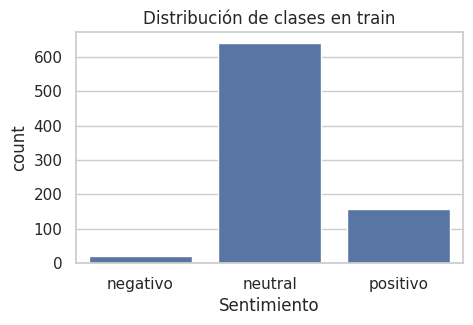

In [7]:
# Distribución de clases
conteo = train["Sentimiento"].value_counts()
print(pd.DataFrame({"n": conteo, "%": (conteo / len(train) * 100).round(1)}))

fig, ax = plt.subplots(figsize=(5, 3))
sns.countplot(data=train, x="Sentimiento", order=["negativo", "neutral", "positivo"], ax=ax)
ax.set_title("Distribución de clases en train")
plt.show()

In [8]:
# Calidad del texto: vacíos, duplicados y solapes entre archivos
for nombre, df in [("train", train), ("test", test), ("submission", sub)]:
    vacios = (df["Comentario"].str.strip() == "").sum()
    duplicados = df["Comentario"].duplicated().sum()
    print(nombre, "vacíos:", vacios, "duplicados:", duplicados)

rep = train[train["Comentario"].duplicated(keep=False)]
conflicto = rep.groupby("Comentario")["Sentimiento"].nunique()
print("Textos repetidos con etiquetas distintas:", (conflicto > 1).sum())
print("Comentarios de submission que están en train:", sub["Comentario"].isin(train["Comentario"]).sum())
print("Comentarios de test que están en train:", test["Comentario"].isin(train["Comentario"]).sum())

train vacíos: 0 duplicados: 9
test vacíos: 0 duplicados: 0
submission vacíos: 0 duplicados: 0
Textos repetidos con etiquetas distintas: 0
Comentarios de submission que están en train: 2
Comentarios de test que están en train: 3


In [9]:
# Atajos posibles entre las columnas y la etiqueta (solo diagnóstico, no se usan como entrada)
print(pd.crosstab(train["Sitio"], train["Sentimiento"]))

# Etiquetas distintas por combinación de sitio y valoración del lugar
distintas = train.groupby(["Sitio", "Valoración_num"])["Sentimiento"].nunique()
print("Máximo de etiquetas por combinación de sitio y valoración:", distintas.max())

# Una regla que solo mira el sitio
regla_sitio = train["Sitio"].map({"Foursquare": "positivo", "Tripadvisor": "neutral"})
acc_regla_sitio = (regla_sitio == train["Sentimiento"]).mean()
print("Accuracy de una regla que solo usa el sitio:", round(acc_regla_sitio, 3))
RESUMEN["acc_regla_solo_sitio"] = round(float(acc_regla_sitio), 4)

# Los negativos están concentrados en muy pocos lugares
print(train[train["label"] == 0]["Nombre del lugar"].value_counts())

# El año de la reseña también va ligado al sitio
train["anio"] = train["Fecha"].str.extract(r"(19\d{2}|20\d{2})")[0].astype(float)
print(train.groupby("Sitio")["anio"].median())

Sentimiento  negativo  neutral  positivo
Sitio                                   
Foursquare          0       42       157
Tripadvisor        22      597         0
Máximo de etiquetas por combinación de sitio y valoración: 1
Accuracy de una regla que solo usa el sitio: 0.922
Nombre del lugar
Plaza de Majagual                        19
Ecoparque Laderas de Villeros Coveñas     3
Name: count, dtype: int64
Sitio
Foursquare     2014.0
Tripadvisor    2019.0
Name: anio, dtype: float64


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (697 > 512). Running this sequence through the model will result in indexing errors


count    818.0
mean      56.2
std       58.4
min        5.0
25%       26.0
50%       39.0
75%       64.0
max      697.0
Name: n_tokens, dtype: float64
p50: 39
p90: 112
p95: 165
p99: 304
max_length 64: truncado 24.6%
max_length 128: truncado 8.4%
max_length 192: truncado 3.3%
max_length 256: truncado 1.2%
             count  mean   std   min   25%   50%   75%    max
Sentimiento                                                  
negativo      22.0  39.5  14.4  24.0  29.0  36.0  44.0   78.0
neutral      639.0  65.6  62.5   5.0  31.0  46.0  75.0  697.0
positivo     157.0  20.1  12.6   5.0  11.0  16.0  27.0   87.0


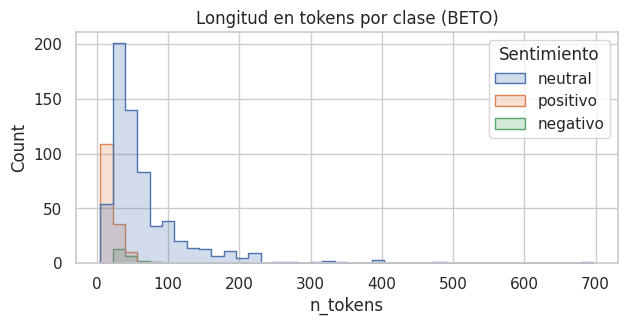

In [10]:
# Longitud en tokens con el tokenizer de BETO
tok_eda = cargar_tokenizer("beto")
train["n_tokens"] = [len(x) for x in tok_eda(train["Comentario"].tolist(), truncation=False)["input_ids"]]
print(train["n_tokens"].describe().round(1))

for p in [50, 90, 95, 99]:
    print(f"p{p}:", int(np.percentile(train["n_tokens"], p)))
for L in [64, 128, 192, 256]:
    print(f"max_length {L}: truncado {(train['n_tokens'] > L).mean() * 100:.1f}%")

print(train.groupby("Sentimiento")["n_tokens"].describe().round(1))

fig, ax = plt.subplots(figsize=(7, 3))
sns.histplot(data=train, x="n_tokens", hue="Sentimiento", bins=40, element="step", ax=ax)
ax.set_title("Longitud en tokens por clase (BETO)")
plt.show()

In [11]:
# Datos personales: búsqueda simple por patrones
patrones = {
    "correo": r"[\w\.-]+@[\w\.-]+\.\w+",
    "telefono": r"(?:\+?57)?\s?3\d{2}[\s-]?\d{3}[\s-]?\d{4}",
    "enlace": r"https?://\S+|www\.\S+",
}
for nombre, patron in patrones.items():
    print(nombre, train["Comentario"].str.contains(patron, regex=True).sum())

# Textos muy cortos, difíciles de clasificar
cortos = train[train["n_tokens"] <= 8][["Comentario", "Sentimiento"]]
print(len(cortos), "textos con 8 tokens o menos")

# Reseñas con lenguaje de queja y etiqueta distinta de negativo (evidencia de ruido de etiqueta)
quejas = r"estafa|inseguro|insegura|sucio|sucia|malo|mala|pésimo|pesimo|no recomiendo|decepcion|robo|peligro"
sospechosos = train[
    train["Comentario"].str.lower().str.contains(quejas, regex=True)
    & (train["Sentimiento"] != "negativo")
]
print(len(sospechosos), "reseñas con lenguaje de queja y etiqueta distinta de negativo")
sospechosos[["Comentario", "Sentimiento"]].head(8)

correo 0
telefono 0
enlace 1
33 textos con 8 tokens o menos
22 reseñas con lenguaje de queja y etiqueta distinta de negativo


,Comentario,Sentimiento
0,"La isla es muy hermosa y tiene unas aguas muy azuladas; pero mi consejo es que se cuiden de las personas, pues la mayoría en la isla son estafadores.",neutral
3,"es un paraíso de playa Para llegar a la isla llegamos a Tolu nos hospedamos en un excelente hotel llamado hotel Caribe Royal, al frente de la playa. Luego c...",neutral
47,"Un paraiso Es una Isla increíble, hay que conocerla para corroborar que su mar es similar al de San Andrés. Nos alojamos en el Hotel Club Múcura, hermoso, l...",neutral
84,"Si no quieren sufrir un trauma psicológico, no se bajen en la isla del acuario, Santa Cruz del Islote. La pequeña isla es una gran sopa de mugre y malos olo...",neutral
99,"Mala atención al cliente, 1:15 esperando una pizza",neutral
142,La opinión sobre esta playa depende de dónde estés ubicado. Hay un contraste entre la hermosura del mar y las playas con la suciedad y dejadez. En nuestro c...,neutral
217,En este momento elmarestaaaa peligrosooooooooo,positivo
256,"La playa es pequeña y dependiendo de la temporada vas a poder encontrar un espacio donde pasar el día. Lo malo es que la playa está muy sucia, se encuentran...",neutral


### Análisis exploratorio
El conjunto de entrenamiento tiene 818 reseñas: 78 % neutrales, 19 % positivas y 2,7 % negativas (22 textos). La mediana es de 39 tokens con el tokenizer de BETO, el 95 % de los textos tiene 165 tokens o menos y hay una cola larga que llega a 697. Hay 9 comentarios duplicados, todos con la misma etiqueta.

Tres hallazgos condicionan el resto del trabajo. Primero, la etiqueta sale de la valoración del lugar y no del texto, así que hay reseñas claramente críticas marcadas como neutrales. Segundo, el sitio explica casi toda la etiqueta (Foursquare solo da neutral o positivo y Tripadvisor solo neutral o negativo), y el estilo del texto delata el sitio: las reseñas positivas son muy cortas (mediana de 16 tokens) y las neutrales largas (mediana de 46). Un modelo puede acertar leyendo el estilo y no el sentimiento. Tercero, los 22 negativos salen de solo dos lugares (la Plaza de Majagual en Tripadvisor, con 19, y un ecoparque de Coveñas, con 3), así que "negativo" se parece más a "reseña de esos lugares" que a una opinión negativa, y en esas reseñas hay textos que elogian el sitio.

### Calidad de los datos
No hay textos vacíos ni datos personales (0 correos, 0 teléfonos y un enlace). Las palabras pegadas por la extracción ("Tamaldecerdo") no se corrigen.

### Factibilidad e hipótesis de trabajo
Con solo el texto se puede superar el baseline léxico, pero el techo lo limita el ruido de etiqueta. Hipótesis: BETO supera a TF-IDF con regresión logística en al menos 0,02 de accuracy y recupera una parte útil de las reseñas negativas.

### Riesgos de calidad y QA
| Riesgo | Cómo se detectó | Evidencia |
|---|---|---|
| Desbalance de clases | Conteo por clase | 2,7 % negativos |
| Etiqueta derivada de la valoración del lugar (fuga si se usa `Valoración_num`) | Agrupación por sitio y valoración | Una sola etiqueta por combinación |
| Clase negativa concentrada en dos lugares | Conteo de negativos por lugar | 19 de la Plaza de Majagual y 3 del ecoparque de Coveñas |
| Atajo por plataforma | Regla que solo usa el sitio y longitud por clase | Accuracy de la regla de sitio (ver celda), medianas de 16, 46 y 36 tokens |
| Ruido de etiqueta | Búsqueda de quejas en reseñas no negativas y revisión manual | Reseñas críticas etiquetadas como neutral o positivo |
| Duplicados | Conteo de textos repetidos | 9 en train, sin conflicto de etiqueta |
| Solape entre archivos | Comparación de textos exactos | 2 en submission y 3 en test ya están en train |
| Textos largos | Percentiles de tokens | p99 de 304, máximo 697 |
| Datos personales | Búsqueda por patrones | 0 correos, 0 teléfonos |

## Fase 2. Ingeniería de datos

### Limpieza y normalización
Se eliminan los enlaces y los espacios repetidos. No se pasa a minúsculas, no se quitan tildes ni palabras vacías, porque BETO distingue mayúsculas y las negaciones cambian el sentido de la reseña. Las palabras pegadas no se corrigen, porque una corrección automática puede inventar palabras.

### Partición de los datos
Se eliminan los textos duplicados y se crean 5 folds estratificados por etiqueta con semilla fija. Con solo 22 negativos, una partición única 80/20 dejaría unos 4 en validación, por eso se usa validación cruzada. El fold 0 es la validación de trabajo para comparar experimentos y los 5 folds se usan para el resultado final con intervalo de confianza. El archivo `test.csv` no se toca hasta la evaluación final y se le quitan los textos que ya están en train.

### Aumento de datos
No se aplicó. Con tan pocos negativos la retrotraducción podría ayudar, pero queda como trabajo futuro.

In [12]:
# Limpieza mínima del texto
def limpiar(t):
    t = re.sub(r"https?://\S+|www\.\S+", " ", str(t))
    return re.sub(r"\s+", " ", t).strip()

for df in (train, test, sub):
    df["texto"] = df["Comentario"].map(limpiar)

# Quitar duplicados exactos antes de partir
n_antes = len(train)
train_u = train.drop_duplicates(subset="texto").reset_index(drop=True)
print("Filas de train:", n_antes, "->", len(train_u))

# Reserva final: test.csv sin los textos que ya están en train
test_eval = test[~test["texto"].isin(set(train_u["texto"]))].reset_index(drop=True)
print("Filas de test.csv:", len(test), "->", len(test_eval), "(sin textos repetidos de train)")

# Folds estratificados por etiqueta
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
train_u["fold"] = -1
for k, (_, val_idx) in enumerate(skf.split(train_u, train_u["label"])):
    train_u.loc[val_idx, "fold"] = k

print(pd.crosstab(train_u["fold"], train_u["Sentimiento"]))
print(pd.crosstab(train_u["fold"], train_u["Sitio"], normalize="index").round(2))

Filas de train: 818 -> 809
Filas de test.csv: 351 -> 348 (sin textos repetidos de train)
Sentimiento  negativo  neutral  positivo
fold                                    
0                   4      126        32
1                   4      126        32
2                   5      126        31
3                   5      126        31
4                   4      126        31
Sitio  Foursquare  Tripadvisor
fold                          
0            0.22         0.78
1            0.28         0.72
2            0.25         0.75
3            0.23         0.77
4            0.24         0.76


In [13]:
# Pruebas sobre la partición (evidencia de QA)
def verificar_particion(tr, va):
    assert len(tr) > 0 and len(va) > 0, "Partición vacía"
    assert set(tr["ID"]).isdisjoint(set(va["ID"])), "Hay IDs en ambas particiones"
    assert set(tr["texto"]).isdisjoint(set(va["texto"])), "Hay textos en ambas particiones"

assert train_u["label"].isin([0, 1, 2]).all(), "Etiquetas fuera de rango"
assert (train_u["texto"].str.len() > 0).all(), "Hay textos vacíos"
assert train_u["texto"].is_unique, "Quedaron textos duplicados"
assert set(train_u["ID"]).isdisjoint(set(test["ID"])), "Hay IDs de train en test.csv"
assert set(train_u["ID"]).isdisjoint(set(sub["ID"])), "Hay IDs de train en submission"
assert set(test_eval["texto"]).isdisjoint(set(train_u["texto"])), "La reserva comparte textos con train"

for k in range(N_FOLDS):
    tr_k = train_u[train_u["fold"] != k]
    va_k = train_u[train_u["fold"] == k]
    verificar_particion(tr_k, va_k)
    assert len(tr_k) + len(va_k) == len(train_u), "Se perdieron filas"
    assert (va_k["label"] == 0).sum() >= 3, "Un fold casi sin negativos"

tr_df = train_u[train_u["fold"] != FOLD_VAL].reset_index(drop=True)
va_df = train_u[train_u["fold"] == FOLD_VAL].reset_index(drop=True)
print("Entrenamiento (fold 0 afuera):", len(tr_df), "| Validación:", len(va_df))
print("Aserciones superadas en los", N_FOLDS, "folds")

Entrenamiento (fold 0 afuera): 647 | Validación: 162
Aserciones superadas en los 5 folds


In [14]:
# Truncamiento con el max_length elegido y tokens desconocidos (por ejemplo emojis)
ids_tr = tok_eda(tr_df["texto"].tolist(), truncation=False)["input_ids"]
largos = np.array([len(x) for x in ids_tr])
print(f"Truncados con max_length {MAX_LEN}: {np.mean(largos > MAX_LEN) * 100:.1f}%")
print("Textos con algún token desconocido:", sum(tok_eda.unk_token_id in x for x in ids_tr))

# Pesos de clase: ninguno, raíz cuadrada o completos
def calcular_pesos(y, modo):
    if modo == "ninguno":
        return None
    presentes = np.unique(y)
    w = np.ones(3)
    w[presentes] = compute_class_weight("balanced", classes=presentes, y=y)
    return np.sqrt(w) if modo == "sqrt" else w

print("Pesos completos:", calcular_pesos(tr_df["label"].values, "completo").round(2))
print("Pesos con raíz:", calcular_pesos(tr_df["label"].values, "sqrt").round(2))

Truncados con max_length 192: 3.1%
Textos con algún token desconocido: 40
Pesos completos: [11.98  0.43  1.73]
Pesos con raíz: [3.46 0.65 1.31]


### Riesgos de calidad y QA de la Fase 2
| Riesgo | Método de QA | Evidencia |
|---|---|---|
| Fuga entre particiones | Aserciones de IDs y textos disjuntos en los 5 folds | Celda de pruebas |
| Duplicados que inflan la validación | Se eliminan antes de partir | 9 textos quitados |
| Pocos negativos por fold | Estratificación y aserción de mínimo 3 por fold | Tabla de folds |
| Texto dañado por la limpieza | Limpieza mínima, sin minúsculas ni quitar tildes | Decisión documentada |
| Pesos de clase muy altos | Se comparan pesos completos y con raíz como experimentos | E2 y E3 |

## Fase 3. Ingeniería del modelo

### Funciones de apoyo
Se definen las métricas, el registro de experimentos, el bucle de entrenamiento y la clase de inferencia. El entrenamiento está escrito en PyTorch plano, sin `Trainer`, para que cada decisión (pérdida, optimizador, scheduler) se vea en el código y se pueda explicar en la defensa.

In [15]:
# Métricas por clase y globales
def metricas(y, pred):
    p, r, f, _ = precision_recall_fscore_support(y, pred, labels=[0, 1, 2], zero_division=0)
    return {
        "acc": accuracy_score(y, pred),
        "f1_macro": float(f.mean()),
        "recall_neg": float(r[0]),
        "precision_por_clase": p, "recall_por_clase": r, "f1_por_clase": f,
    }

# Registro de experimentos en CSV (si el id ya existe, se reemplaza)
def registrar(fila):
    fila = {**fila, "fecha": datetime.now().strftime("%Y-%m-%d %H:%M")}
    if os.path.exists(REGISTRO_PATH):
        reg = pd.read_csv(REGISTRO_PATH)
        reg = reg[reg["id"] != fila["id"]]
        reg = pd.concat([reg, pd.DataFrame([fila])], ignore_index=True)
    else:
        reg = pd.DataFrame([fila])
    reg.to_csv(REGISTRO_PATH, index=False)

# Tokenización y armado de lotes con relleno dinámico
def tokenizar(tokenizer, textos, max_len):
    return tokenizer(list(textos), truncation=True, max_length=max_len)["input_ids"]

def armar_lote(ids_lista, pad_id):
    largo = max(len(x) for x in ids_lista)
    ids = torch.full((len(ids_lista), largo), pad_id, dtype=torch.long)
    mask = torch.zeros((len(ids_lista), largo), dtype=torch.long)
    for i, x in enumerate(ids_lista):
        ids[i, :len(x)] = torch.tensor(x)
        mask[i, :len(x)] = 1
    return ids, mask

# Probabilidades por clase, conservando el orden original de los textos
@torch.no_grad()
def probs_modelo(model, ids_lista, pad_id, batch_size=64, amp=None):
    model.eval()
    dev = next(model.parameters()).device
    amp = (dev.type == "cuda") if amp is None else amp
    orden = np.argsort([len(x) for x in ids_lista])
    salida = np.zeros((len(ids_lista), 3), dtype=np.float32)
    for i in range(0, len(orden), batch_size):
        idx = orden[i:i + batch_size]
        ids, mask = armar_lote([ids_lista[j] for j in idx], pad_id)
        with torch.autocast(device_type=dev.type, dtype=torch.float16, enabled=amp):
            logits = model(input_ids=ids.to(dev), attention_mask=mask.to(dev)).logits
        salida[idx] = torch.softmax(logits.float(), dim=-1).cpu().numpy()
    return salida

def liberar_memoria():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [16]:
# Bucle de entrenamiento con AdamW, warmup lineal, pérdida con pesos y precisión mixta
def entrenar(cfg, tr, va=None, semilla=SEED, devolver_modelo=False):
    set_seed(semilla)
    t0 = time.time()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    ruta = resolver_checkpoint(cfg["checkpoint"])
    tokenizer = AutoTokenizer.from_pretrained(ruta)
    model = AutoModelForSequenceClassification.from_pretrained(
        ruta, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID, ignore_mismatched_sizes=True
    ).to(DEVICE)

    # Congelar el encoder deja entrenable solo la cabeza de clasificación
    if cfg["congelar"]:
        for p in model.base_model.parameters():
            p.requires_grad = False

    pad_id = tokenizer.pad_token_id
    ids_tr = tokenizer(tr["texto"].tolist(), truncation=True, max_length=cfg["max_len"])["input_ids"]
    y_tr = tr["label"].values
    if va is not None:
        ids_va = tokenizer(va["texto"].tolist(), truncation=True, max_length=cfg["max_len"])["input_ids"]
        y_va = va["label"].values

    pesos = calcular_pesos(y_tr, cfg["pesos"])
    w_t = None if pesos is None else torch.tensor(pesos, dtype=torch.float, device=DEVICE)
    loss_fn = nn.CrossEntropyLoss(weight=w_t)

    # Sin decaimiento de pesos en sesgos ni normalizaciones
    sin_decay = ["bias", "LayerNorm.weight", "layer_norm.weight"]
    nombres = [(n, p) for n, p in model.named_parameters() if p.requires_grad]
    grupos = [
        {"params": [p for n, p in nombres if not any(s in n for s in sin_decay)], "weight_decay": 0.01},
        {"params": [p for n, p in nombres if any(s in n for s in sin_decay)], "weight_decay": 0.0},
    ]
    opt = torch.optim.AdamW(grupos, lr=cfg["lr"])
    bs = cfg["batch_size"]
    total = math.ceil(len(ids_tr) / bs) * cfg["epochs"]
    sched = get_linear_schedule_with_warmup(opt, int(0.1 * total), total)
    scaler = torch.amp.GradScaler("cuda", enabled=USAR_AMP)
    rng = np.random.default_rng(semilla)

    historia = []
    probs_val = None
    for ep in range(cfg["epochs"]):
        model.train()
        orden = rng.permutation(len(ids_tr))
        suma = 0.0
        for i in range(0, len(orden), bs):
            idx = orden[i:i + bs]
            ids, mask = armar_lote([ids_tr[j] for j in idx], pad_id)
            y = torch.tensor(y_tr[idx], dtype=torch.long, device=DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USAR_AMP):
                logits = model(input_ids=ids.to(DEVICE), attention_mask=mask.to(DEVICE)).logits
            loss = loss_fn(logits.float(), y)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()
            sched.step()
            suma += loss.item() * len(idx)

        fila = {"epoca": ep + 1, "train_loss": suma / len(ids_tr)}
        if va is not None:
            probs_val = probs_modelo(model, ids_va, pad_id)
            m = metricas(y_va, probs_val.argmax(1))
            fila["val_loss"] = float(-np.log(probs_val[np.arange(len(y_va)), y_va] + 1e-12).mean())
            fila["val_acc"] = m["acc"]
            fila["val_f1_macro"] = m["f1_macro"]
        historia.append(fila)
        print("  ", {k: round(v, 4) for k, v in fila.items()})

    res = {
        "historia": historia,
        "probs_val": probs_val,
        "tiempo_s": round(time.time() - t0, 1),
        "mem_gpu_mb": round(torch.cuda.max_memory_allocated() / 2**20) if torch.cuda.is_available() else 0,
        "model": model if devolver_modelo else None,
        "tokenizer": tokenizer if devolver_modelo else None,
    }
    if not devolver_modelo:
        del model, opt
        liberar_memoria()
    return res

In [17]:
# Clase de inferencia: carga un modelo guardado y devuelve probabilidades
class Clasificador:
    def __init__(self, ruta, device=None):
        self.device = device or DEVICE
        self.tokenizer = AutoTokenizer.from_pretrained(ruta)
        self.model = AutoModelForSequenceClassification.from_pretrained(ruta).to(self.device).eval()
        with open(os.path.join(ruta, "config_inferencia.json"), encoding="utf-8") as f:
            self.max_len = json.load(f)["max_len"]

    def probs(self, textos, batch_size=64):
        ids = tokenizar(self.tokenizer, [limpiar(t) for t in textos], self.max_len)
        return probs_modelo(self.model, ids, self.tokenizer.pad_token_id, batch_size, amp=False)

    def predecir(self, textos):
        p = self.probs(textos)
        return p.argmax(1), p

### Baseline clásico
Se entrenan tres referencias en los mismos 5 folds que usará el Transformer:

- **B0:** predecir siempre la clase mayoritaria.
- **B1:** TF-IDF de palabras (1 a 2 gramas) y de caracteres (2 a 5) con regresión logística, con y sin pesos de clase. El mejor de los dos es el baseline de referencia.
- **B2:** regresión logística que solo ve la forma del texto (longitud, signos de exclamación, mayúsculas). Sirve para medir cuánta accuracy sale del atajo por estilo y no del contenido.

También se repite B1 con una partición agrupada por lugar, para ver cuánto se infla la métrica cuando los mismos lugares aparecen en entrenamiento y validación.

In [18]:
def modelo_tfidf(con_pesos, C=1.0):
    return make_pipeline(
        make_union(
            TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
            TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=2, sublinear_tf=True),
        ),
        LogisticRegression(C=C, max_iter=3000, class_weight="balanced" if con_pesos else None),
    )

def rasgos_forma(textos):
    s = pd.Series(list(textos))
    largo = s.str.len() + 1
    return np.c_[
        np.log1p(s.str.len()), np.log1p(s.str.split().str.len()),
        s.str.count("!"), s.str.count(r"[?¿]"),
        s.str.count(r"[A-ZÁÉÍÓÚÑ]") / largo,
    ]

def modelo_forma():
    return make_pipeline(FunctionTransformer(rasgos_forma), StandardScaler(),
                         LogisticRegression(max_iter=1000, class_weight="balanced"))

class Mayoritaria:
    def fit(self, X, y):
        self.c = int(pd.Series(y).value_counts().idxmax())
        return self
    def predict(self, X):
        return np.full(len(X), self.c)

def cv_sklearn(fabrica):
    oof = np.zeros(len(train_u), dtype=int)
    for k in range(N_FOLDS):
        tr = train_u[train_u["fold"] != k]
        va = train_u[train_u["fold"] == k]
        mod = fabrica()
        mod.fit(tr["texto"].tolist(), tr["label"].values)
        oof[va.index] = mod.predict(va["texto"].tolist())
    return oof

y_all = train_u["label"].values
BASES = {
    "B0": ("Clase mayoritaria", Mayoritaria),
    "B1a": ("TF-IDF y regresión logística sin pesos", lambda: modelo_tfidf(False)),
    "B1b": ("TF-IDF y regresión logística con pesos", lambda: modelo_tfidf(True)),
    "B2": ("Solo forma del texto (longitud, signos)", modelo_forma),
}
oof_bases = {}
filas = []
for bid, (nombre, fabrica) in BASES.items():
    oof = cv_sklearn(fabrica)
    oof_bases[bid] = oof
    accs_fold = [accuracy_score(y_all[train_u["fold"] == k], oof[train_u["fold"] == k]) for k in range(N_FOLDS)]
    m = metricas(y_all, oof)
    m0 = metricas(y_all[train_u["fold"] == FOLD_VAL], oof[train_u["fold"] == FOLD_VAL])
    filas.append({"id": bid, "modelo": nombre, "acc_cv": m["acc"], "std_folds": np.std(accs_fold),
                  "f1_macro_cv": m["f1_macro"], "recall_neg_cv": m["recall_neg"], "acc_fold0": m0["acc"]})
    registrar({"id": bid, "tipo": "baseline", "cambio": nombre, "checkpoint": "sklearn",
               "acc": m0["acc"], "f1_macro": m0["f1_macro"], "recall_neg": m0["recall_neg"],
               "acc_cv": m["acc"]})

tabla_bases = pd.DataFrame(filas).round(3)
display(tabla_bases)

# El baseline de referencia es el mejor TF-IDF por accuracy en validación cruzada
ref_id = tabla_bases[tabla_bases["id"].isin(["B1a", "B1b"])].sort_values("acc_cv", ascending=False).iloc[0]["id"]
fabrica_base = BASES[ref_id][1]
oof_base = oof_bases[ref_id]
RESUMEN["baseline_ref"] = ref_id
RESUMEN["acc_cv_base"] = round(float(accuracy_score(y_all, oof_base)), 4)
RESUMEN["f1_macro_cv_base"] = round(float(metricas(y_all, oof_base)["f1_macro"]), 4)
RESUMEN["recall_neg_cv_base"] = round(float(metricas(y_all, oof_base)["recall_neg"]), 4)
RESUMEN["acc_cv_solo_forma"] = round(float(accuracy_score(y_all, oof_bases["B2"])), 4)
print("Baseline de referencia:", ref_id, "| accuracy CV:", RESUMEN["acc_cv_base"])

,id,modelo,acc_cv,std_folds,f1_macro_cv,recall_neg_cv,acc_fold0
0,B0,Clase mayoritaria,0.779,0.002,0.292,0.000,0.778
1,B1a,TF-IDF y regresión logística sin pesos,0.863,0.020,0.516,0.000,0.895
2,B1b,TF-IDF y regresión logística con pesos,0.897,0.031,0.729,0.318,0.951
3,B2,"Solo forma del texto (longitud, signos)",0.612,0.029,0.527,0.818,0.654


Baseline de referencia: B1b | accuracy CV: 0.8974


In [19]:
# Mismo baseline con partición agrupada por lugar: mide cuánto se infla la validación aleatoria
oof_g = np.zeros(len(train_u), dtype=int)
grupos = train_u["Nombre del lugar"].values
for tr_idx, va_idx in GroupKFold(n_splits=N_FOLDS).split(train_u, groups=grupos):
    mod = fabrica_base()
    mod.fit(train_u.loc[tr_idx, "texto"].tolist(), y_all[tr_idx])
    oof_g[va_idx] = mod.predict(train_u.loc[va_idx, "texto"].tolist())

acc_alea = accuracy_score(y_all, oof_base)
acc_grupo = accuracy_score(y_all, oof_g)
print("Accuracy con folds aleatorios:", round(acc_alea, 3))
print("Accuracy con folds agrupados por lugar:", round(acc_grupo, 3))
print("Recall de negativos con folds agrupados:", round(metricas(y_all, oof_g)["recall_neg"], 3))
RESUMEN["acc_cv_base_agrupado_por_lugar"] = round(float(acc_grupo), 4)

Accuracy con folds aleatorios: 0.897
Accuracy con folds agrupados por lugar: 0.841
Recall de negativos con folds agrupados: 0.0


### Selección de checkpoints
Se comparan tres modelos preentrenados. Los tamaños son aproximados y las licencias deben confirmarse en la ficha de cada modelo antes de citarlas en el documento.

| Clave | Modelo | Parámetros | Preentrenamiento | Licencia |
|---|---|---|---|---|
| `beto` | dccuchile/bert-base-spanish-wwm-cased | unos 110 M | Solo español (Wikipedia y corpus OPUS), con enmascaramiento de palabras completas | CC BY 4.0 |
| `roberta_bne` | PlanTL-GOB-ES/roberta-base-bne | unos 125 M | Solo español (rastreos web de la Biblioteca Nacional de España) | Apache 2.0 |
| `xlmr` | FacebookAI/xlm-roberta-base | unos 278 M, la mayoría en embeddings | 100 idiomas (CC100) | MIT |

BETO y RoBERTa BNE son monolingües en español, así que su vocabulario cubre mejor el idioma de las reseñas. XLM-R es multilingüe y más grande, y sirve para saber si la cobertura de idiomas ayuda o solo añade tamaño.

### Arquitectura y configuración de entrenamiento
Encoder preentrenado con una cabeza de clasificación lineal sobre el token inicial, de 3 salidas. En el ajuste fino se entrenan todos los pesos, salvo en el experimento E6 donde se congela el encoder y solo aprende la cabeza.

| Elemento | Valor |
|---|---|
| Optimizador | AdamW, decaimiento de pesos 0,01 (no se aplica a sesgos ni normalizaciones) |
| Learning rate | 2e-5 en la base |
| Scheduler | Lineal con warmup del 10 % de los pasos |
| Batch size | 16 |
| Épocas | 6, número fijo |
| Pérdida | Entropía cruzada, con pesos de clase según el experimento |
| Recorte de gradiente | 1,0 |
| Precisión | Mixta fp16 en GPU |
| Early stopping | No se usa: con una validación de unos 160 textos y 4 negativos, elegir la mejor época sobre ella sobreajusta a esa validación. En su lugar se fija el número de épocas y se revisan las curvas. |

### Diseño experimental
Cada experimento cambia un solo factor respecto a la configuración base E1 y se evalúa en el fold 0. Las diferencias menores a 0,02 de accuracy están dentro del ruido de una validación tan pequeña, así que la comparación se confirma después con validación cruzada. En E6 el learning rate sube a 1e-3 porque, con el encoder congelado, la cabeza no aprende con 2e-5; ese ajuste va ligado al cambio y queda explícito en la tabla.

In [20]:
BASE = {"checkpoint": "beto", "lr": 2e-5, "epochs": 6, "batch_size": 16,
        "max_len": MAX_LEN, "pesos": "ninguno", "congelar": False}

EXPERIMENTOS = [
    ("E1", "Configuración base con BETO", {}),
    ("E2", "Pesos de clase con raíz cuadrada", {"pesos": "sqrt"}),
    ("E3", "Pesos de clase completos", {"pesos": "completo"}),
    ("E4", "max_length de 128", {"max_len": 128}),
    ("E5", "Learning rate de 5e-5", {"lr": 5e-5}),
    ("E6", "Encoder congelado (con lr de 1e-3 para la cabeza)", {"congelar": True, "lr": 1e-3}),
    ("E7", "Checkpoint XLM-R base", {"checkpoint": "xlmr"}),
    ("E8", "Checkpoint RoBERTa BNE", {"checkpoint": "roberta_bne"}),
]

FORZAR = False  # poner True para repetir corridas ya registradas

CONFIGS = json.load(open(CONFIGS_PATH)) if os.path.exists(CONFIGS_PATH) else {}
hechos = set()
if os.path.exists(REGISTRO_PATH):
    reg_prev = pd.read_csv(REGISTRO_PATH)
    hechos = set(reg_prev.loc[reg_prev["tipo"] == "transformer", "id"])

y_va0 = va_df["label"].values
for exp_id, cambio, over in EXPERIMENTOS:
    if exp_id in hechos and not FORZAR and exp_id in CONFIGS:
        print(exp_id, "ya registrado, se omite")
        continue
    cfg = {**BASE, **over}
    print(f"\n{exp_id}: {cambio}")
    try:
        res = entrenar(cfg, tr_df, va_df)
    except Exception as e:
        print("  No se pudo correr", exp_id, "->", repr(e)[:300])
        liberar_memoria()
        continue
    m = metricas(y_va0, res["probs_val"].argmax(1))
    hist = pd.DataFrame(res["historia"])
    registrar({
        "id": exp_id, "tipo": "transformer", "cambio": cambio,
        "checkpoint": cfg["checkpoint"], "lr": cfg["lr"], "epochs": cfg["epochs"],
        "batch_size": cfg["batch_size"], "max_len": cfg["max_len"],
        "pesos": cfg["pesos"], "congelar": cfg["congelar"],
        "acc": m["acc"], "f1_macro": m["f1_macro"], "recall_neg": m["recall_neg"],
        "mejor_epoca": int(hist["val_acc"].idxmax()) + 1,
        "tiempo_s": res["tiempo_s"], "mem_gpu_mb": res["mem_gpu_mb"],
    })
    CONFIGS[exp_id] = cfg
    json.dump(CONFIGS, open(CONFIGS_PATH, "w"), indent=2)
    json.dump(res["historia"], open(os.path.join(CURVAS_DIR, f"{exp_id}.json"), "w"))
    print(f"  accuracy {m['acc']:.3f} | F1 macro {m['f1_macro']:.3f} | recall negativo {m['recall_neg']:.3f} | {res['tiempo_s']} s")


E1: Configuración base con BETO


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  440MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   {'epoca': 1, 'train_loss': 0.8538, 'val_loss': 0.5601, 'val_acc': 0.7778, 'val_f1_macro': 0.2917}
   {'epoca': 2, 'train_loss': 0.4761, 'val_loss': 0.3078, 'val_acc': 0.9259, 'val_f1_macro': 0.6094}
   {'epoca': 3, 'train_loss': 0.3638, 'val_loss': 0.3032, 'val_acc': 0.9074, 'val_f1_macro': 0.5854}
   {'epoca': 4, 'train_loss': 0.3389, 'val_loss': 0.223, 'val_acc': 0.9198, 'val_f1_macro': 0.599}
   {'epoca': 5, 'train_loss': 0.2726, 'val_loss': 0.2618, 'val_acc': 0.9259, 'val_f1_macro': 0.6082}
   {'epoca': 6, 'train_loss': 0.2446, 'val_loss': 0.235, 'val_acc': 0.9136, 'val_f1_macro': 0.5932}
  accuracy 0.914 | F1 macro 0.593 | recall negativo 0.000 | 67.2 s

E8: Checkpoint RoBERTa BNE
  No se pudo correr E8 -> ValueError("Couldn't instantiate the backend tokenizer from one of: \n(1) a `tokenizers` library serialization file, \n(2) a slow tokenizer instance to convert or \n(3) an equivalent slow tokenizer class to instantiate and convert. \nYou need to have sentencepiece or tiktoken

In [21]:
# Tabla de experimentos (evidencia de trazabilidad)
reg = pd.read_csv(REGISTRO_PATH)
cols = ["id", "cambio", "checkpoint", "lr", "max_len", "pesos", "congelar",
        "acc", "f1_macro", "recall_neg", "mejor_epoca", "tiempo_s", "mem_gpu_mb"]
reg_tf = reg[reg["tipo"] == "transformer"].copy()
assert len(reg_tf) > 0, "Ninguna corrida de Transformer terminó, revisar los errores de la celda anterior (Internet o modelos como input)"
display(reg_tf[cols].round(3))
print("Corridas de Transformer registradas:", len(reg_tf), "(mínimo exigido: 5)")

# La configuración final es la corrida con mayor accuracy (desempate por F1 macro)
mejor = reg_tf.sort_values(["acc", "f1_macro"], ascending=False).iloc[0]
MEJOR_ID = mejor["id"]
CFG_FINAL = CONFIGS[MEJOR_ID]
print("\nConfiguración elegida:", MEJOR_ID, "->", CFG_FINAL)
RESUMEN["config_final_id"] = MEJOR_ID
RESUMEN["config_final"] = CFG_FINAL
RESUMEN["acc_fold0_mejor"] = round(float(mejor["acc"]), 4)

,id,cambio,checkpoint,lr,max_len,pesos,congelar,acc,f1_macro,recall_neg,mejor_epoca,tiempo_s,mem_gpu_mb
4,E1,Configuración base con BETO,beto,0.000,192.0,ninguno,False,0.944,0.883,1.0,2.0,41.5,2696.0
5,E2,Pesos de clase con raíz cuadrada,beto,0.000,192.0,sqrt,False,0.951,0.914,1.0,3.0,35.7,2696.0
6,E3,Pesos de clase completos,beto,0.000,192.0,completo,False,0.938,0.858,1.0,3.0,36.1,2698.0
7,E4,max_length de 128,beto,0.000,128.0,ninguno,False,0.957,0.953,1.0,5.0,31.6,2298.0
8,E5,Learning rate de 5e-5,beto,0.000,192.0,ninguno,False,0.951,0.914,1.0,3.0,37.2,2692.0
9,E6,Encoder congelado (con lr de 1e-3 para la cabeza),beto,0.001,192.0,ninguno,True,0.895,0.569,0.0,5.0,11.0,593.0
10,E7,Checkpoint XLM-R base,xlmr,0.000,192.0,ninguno,False,0.914,0.593,0.0,2.0,67.2,5355.0


Corridas de Transformer registradas: 7 (mínimo exigido: 5)

Configuración elegida: E4 -> {'checkpoint': 'beto', 'lr': 2e-05, 'epochs': 6, 'batch_size': 16, 'max_len': 128, 'pesos': 'ninguno', 'congelar': False}


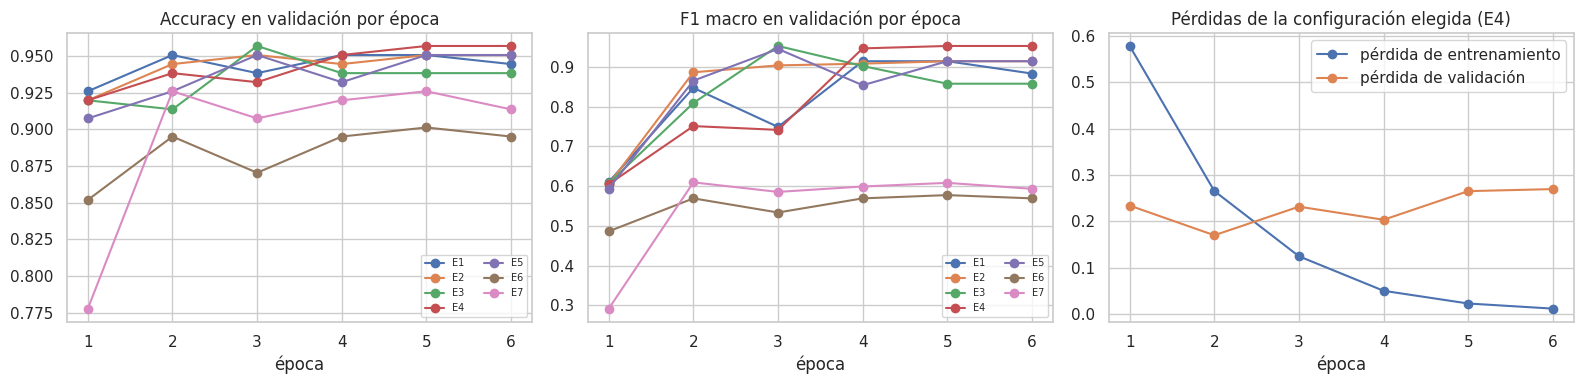

Época con menor pérdida de validación: 2 de 6
Pérdida de validación en la última época: 0.269 | mínima: 0.17
Pérdida de entrenamiento en la última época: 0.012


In [22]:
# Curvas de entrenamiento y validación
curvas = {f[:-5]: pd.DataFrame(json.load(open(os.path.join(CURVAS_DIR, f))))
          for f in sorted(os.listdir(CURVAS_DIR)) if f.endswith(".json")}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for k, h in curvas.items():
    axes[0].plot(h["epoca"], h["val_acc"], marker="o", label=k)
    axes[1].plot(h["epoca"], h["val_f1_macro"], marker="o", label=k)
axes[0].set_title("Accuracy en validación por época")
axes[1].set_title("F1 macro en validación por época")
for ax in axes[:2]:
    ax.set_xlabel("época")
    ax.legend(fontsize=7, ncol=2)

h = curvas[MEJOR_ID]
axes[2].plot(h["epoca"], h["train_loss"], marker="o", label="pérdida de entrenamiento")
axes[2].plot(h["epoca"], h["val_loss"], marker="o", label="pérdida de validación")
axes[2].set_title(f"Pérdidas de la configuración elegida ({MEJOR_ID})")
axes[2].set_xlabel("época")
axes[2].legend()
plt.tight_layout()
plt.show()

# Diagnóstico de sobreajuste sobre la corrida elegida
ep_min = int(h["val_loss"].idxmin()) + 1
print("Época con menor pérdida de validación:", ep_min, "de", len(h))
print("Pérdida de validación en la última época:", round(h["val_loss"].iloc[-1], 3),
      "| mínima:", round(h["val_loss"].min(), 3))
print("Pérdida de entrenamiento en la última época:", round(h["train_loss"].iloc[-1], 3))

### Riesgos de calidad y QA de la Fase 3
| Riesgo | Método de QA | Evidencia |
|---|---|---|
| Sobreajuste a la validación del fold 0 | Confirmar con validación cruzada de 5 folds y no elegir época sobre la validación | Sección de Fase 4 |
| Sobreajuste al leaderboard público | Decidir con validación local y registrar cada envío | Tabla de envíos |
| Comparación injusta con el baseline | Mismos folds, misma semilla y mismo texto limpio | Celda de baselines |
| Experimentos no trazables | Cada corrida se guarda en CSV con configuración, métrica y tiempo | `registro_experimentos.csv` |
| Variación entre ejecuciones | Semilla fija, `cudnn` determinista, versiones registradas | `env_info.json` |

El registro de envíos a Kaggle se lleva con la función de abajo. Cada vez que se suba un archivo, hay que anotar el puntaje público para tener evidencia de cuántos envíos se usaron para decidir.

In [23]:
# Registro manual de envíos a Kaggle
ENVIOS_PATH = os.path.join(EXP_DIR, "envios_kaggle.csv")

def registrar_envio(descripcion, puntaje_publico):
    fila = {"fecha": datetime.now().strftime("%Y-%m-%d %H:%M"),
            "descripcion": descripcion, "puntaje_publico": puntaje_publico}
    prev = pd.read_csv(ENVIOS_PATH) if os.path.exists(ENVIOS_PATH) else pd.DataFrame()
    pd.concat([prev, pd.DataFrame([fila])], ignore_index=True).to_csv(ENVIOS_PATH, index=False)
    print("Envíos registrados:", len(prev) + 1)

## Fase 4. Evaluación del modelo

La evaluación tiene dos partes. Primero, validación cruzada de 5 folds con la configuración elegida, que da una estimación sin sesgo de selección y las predicciones fuera de fold de las 809 reseñas (incluye los 22 negativos). Segundo, un modelo final entrenado con todo train y evaluado una sola vez sobre la reserva `test.csv`.

### Validación cruzada de la configuración elegida
En cada fold se entrena el número fijo de épocas y se toma la última, sin escoger la mejor, para que la estimación no quede inflada.

In [24]:
OOF_PATH = os.path.join(EXP_DIR, "oof_probs.npy")
FORZAR_CV = False

if os.path.exists(OOF_PATH) and not FORZAR_CV:
    oof_probs = np.load(OOF_PATH)
    print("Predicciones fuera de fold cargadas desde disco")
else:
    oof_probs = np.zeros((len(train_u), 3), dtype=np.float32)
    t0 = time.time()
    for k in range(N_FOLDS):
        print(f"\nFold {k}")
        tr_k = train_u[train_u["fold"] != k].reset_index(drop=True)
        va_k = train_u[train_u["fold"] == k]
        res = entrenar(CFG_FINAL, tr_k, va_k.reset_index(drop=True))
        oof_probs[va_k.index] = res["probs_val"]
    np.save(OOF_PATH, oof_probs)
    registrar({"id": "CV", "tipo": "validacion_cruzada", "cambio": f"5 folds con la configuración {MEJOR_ID}",
               "checkpoint": CFG_FINAL["checkpoint"], "tiempo_s": round(time.time() - t0, 1),
               "acc_cv": float(accuracy_score(y_all, oof_probs.argmax(1)))})

oof_pred = oof_probs.argmax(1)

# Resultado por fold y comparación con el baseline en los mismos folds
filas = []
for k in range(N_FOLDS):
    msk = (train_u["fold"] == k).values
    filas.append({"fold": k, "n": int(msk.sum()),
                  "acc_modelo": accuracy_score(y_all[msk], oof_pred[msk]),
                  "acc_baseline": accuracy_score(y_all[msk], oof_base[msk]),
                  "recall_neg_modelo": metricas(y_all[msk], oof_pred[msk])["recall_neg"]})
tabla_folds = pd.DataFrame(filas)
display(tabla_folds.round(3))
print("Accuracy media por fold: modelo", round(tabla_folds["acc_modelo"].mean(), 3),
      "+/-", round(tabla_folds["acc_modelo"].std(), 3),
      "| baseline", round(tabla_folds["acc_baseline"].mean(), 3))


Fold 0


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

   {'epoca': 1, 'train_loss': 0.5781, 'val_loss': 0.2339, 'val_acc': 0.9198, 'val_f1_macro': 0.6048}
   {'epoca': 2, 'train_loss': 0.2653, 'val_loss': 0.17, 'val_acc': 0.9383, 'val_f1_macro': 0.751}
   {'epoca': 3, 'train_loss': 0.1246, 'val_loss': 0.2316, 'val_acc': 0.9321, 'val_f1_macro': 0.7414}
   {'epoca': 4, 'train_loss': 0.0502, 'val_loss': 0.2034, 'val_acc': 0.9506, 'val_f1_macro': 0.9465}
   {'epoca': 5, 'train_loss': 0.0228, 'val_loss': 0.2651, 'val_acc': 0.9568, 'val_f1_macro': 0.9526}
   {'epoca': 6, 'train_loss': 0.0117, 'val_loss': 0.2695, 'val_acc': 0.9568, 'val_f1_macro': 0.9526}

Fold 1


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

   {'epoca': 1, 'train_loss': 0.6222, 'val_loss': 0.2266, 'val_acc': 0.9068, 'val_f1_macro': 0.5905}
   {'epoca': 2, 'train_loss': 0.2182, 'val_loss': 0.189, 'val_acc': 0.9193, 'val_f1_macro': 0.7308}
   {'epoca': 3, 'train_loss': 0.1107, 'val_loss': 0.2091, 'val_acc': 0.9255, 'val_f1_macro': 0.7366}
   {'epoca': 4, 'train_loss': 0.0371, 'val_loss': 0.2468, 'val_acc': 0.9317, 'val_f1_macro': 0.7399}
   {'epoca': 5, 'train_loss': 0.0262, 'val_loss': 0.2188, 'val_acc': 0.9317, 'val_f1_macro': 0.8238}
   {'epoca': 6, 'train_loss': 0.0163, 'val_loss': 0.2261, 'val_acc': 0.9317, 'val_f1_macro': 0.8238}


,fold,n,acc_modelo,acc_baseline,recall_neg_modelo
0,0,162,0.957,0.951,1.0
1,1,162,0.901,0.852,0.5
2,2,162,0.932,0.895,0.4
3,3,162,0.920,0.895,0.2
4,4,161,0.932,0.894,0.5


Accuracy media por fold: modelo 0.928 +/- 0.02 | baseline 0.897


### Métricas oficiales y complementarias
La métrica oficial es la accuracy. Se reportan además precisión, recall y F1 por clase, F1 macro y la matriz de confusión, con intervalos de confianza por bootstrap (1000 remuestreos).

In [25]:
# Bootstrap de intervalos de confianza
def ic_bootstrap(y, pred, fn, n=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        vals.append(fn(y[idx], pred[idx]))
    return np.percentile(vals, [2.5, 97.5])

f_acc = lambda y, p: accuracy_score(y, p)
f_f1 = lambda y, p: metricas(y, p)["f1_macro"]
f_rneg = lambda y, p: metricas(y, p)["recall_neg"]

def resumen_con_ic(y, pred, nombre):
    m = metricas(y, pred)
    filas = []
    for etiqueta, valor, fn in [("accuracy (oficial)", m["acc"], f_acc),
                                ("F1 macro", m["f1_macro"], f_f1),
                                ("recall de negativos", m["recall_neg"], f_rneg)]:
        lo, hi = ic_bootstrap(y, pred, fn)
        filas.append({"conjunto": nombre, "métrica": etiqueta, "valor": valor, "IC 95% inf": lo, "IC 95% sup": hi})
    return pd.DataFrame(filas)

# Modelo y baseline sobre las predicciones fuera de fold
tabla_ic = pd.concat([resumen_con_ic(y_all, oof_pred, "modelo (CV)"),
                      resumen_con_ic(y_all, oof_base, "baseline (CV)")])
display(tabla_ic.round(3))

# Diferencia pareada de accuracy entre modelo y baseline
rng = np.random.default_rng(SEED)
dif = []
for _ in range(1000):
    idx = rng.integers(0, len(y_all), len(y_all))
    dif.append(accuracy_score(y_all[idx], oof_pred[idx]) - accuracy_score(y_all[idx], oof_base[idx]))
dif_media = accuracy_score(y_all, oof_pred) - accuracy_score(y_all, oof_base)
dif_ic = np.percentile(dif, [2.5, 97.5])
print(f"Diferencia de accuracy modelo menos baseline: {dif_media:.3f} (IC 95%: {dif_ic[0]:.3f} a {dif_ic[1]:.3f})")

m_cv = metricas(y_all, oof_pred)
RESUMEN["acc_cv_modelo"] = round(float(m_cv["acc"]), 4)
RESUMEN["f1_macro_cv_modelo"] = round(float(m_cv["f1_macro"]), 4)
RESUMEN["recall_neg_cv"] = round(float(m_cv["recall_neg"]), 4)
RESUMEN["dif_acc_modelo_menos_base"] = round(float(dif_media), 4)
RESUMEN["dif_acc_ic"] = [round(float(dif_ic[0]), 4), round(float(dif_ic[1]), 4)]

,conjunto,métrica,valor,IC 95% inf,IC 95% sup
0,modelo (CV),accuracy (oficial),0.928,0.910,0.946
1,modelo (CV),F1 macro,0.817,0.737,0.879
2,modelo (CV),recall de negativos,0.500,0.280,0.714
0,baseline (CV),accuracy (oficial),0.897,0.876,0.918
1,baseline (CV),F1 macro,0.729,0.639,0.799
2,baseline (CV),recall de negativos,0.318,0.133,0.524


Diferencia de accuracy modelo menos baseline: 0.031 (IC 95%: 0.011 a 0.052)


              precision    recall  f1-score   support

    negativo      0.917     0.500     0.647        22
     neutral      0.946     0.965     0.955       630
    positivo      0.857     0.841     0.849       157

    accuracy                          0.928       809
   macro avg      0.906     0.769     0.817       809
weighted avg      0.928     0.928     0.926       809



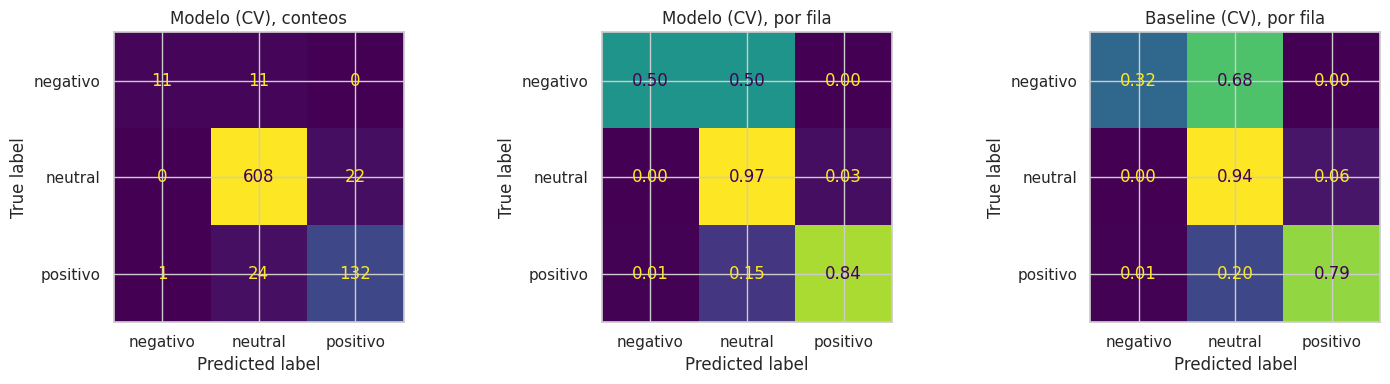

In [26]:
# Reporte por clase y matrices de confusión
print(classification_report(y_all, oof_pred, target_names=NOMBRES_CLASES, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ConfusionMatrixDisplay.from_predictions(y_all, oof_pred, display_labels=NOMBRES_CLASES, ax=axes[0], colorbar=False)
axes[0].set_title("Modelo (CV), conteos")
ConfusionMatrixDisplay.from_predictions(y_all, oof_pred, display_labels=NOMBRES_CLASES, normalize="true",
                                        values_format=".2f", ax=axes[1], colorbar=False)
axes[1].set_title("Modelo (CV), por fila")
ConfusionMatrixDisplay.from_predictions(y_all, oof_base, display_labels=NOMBRES_CLASES, normalize="true",
                                        values_format=".2f", ax=axes[2], colorbar=False)
axes[2].set_title("Baseline (CV), por fila")
plt.tight_layout()
plt.show()

### Modelo final y evaluación en la reserva
El modelo final se entrena con todo train (sin duplicados) y el mismo número de épocas, se guarda en disco y se evalúa una sola vez en `test.csv`. A partir de aquí el notebook trabaja con el modelo cargado desde el disco, igual que lo haría un script de inferencia independiente. El baseline se reentrena con todo train para compararlo en la misma reserva.

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

   {'epoca': 1, 'train_loss': 0.5667}
   {'epoca': 2, 'train_loss': 0.2048}
   {'epoca': 3, 'train_loss': 0.0868}
   {'epoca': 4, 'train_loss': 0.0303}
   {'epoca': 5, 'train_loss': 0.0182}
   {'epoca': 6, 'train_loss': 0.0127}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,conjunto,métrica,valor,IC 95% inf,IC 95% sup
0,modelo (reserva),accuracy (oficial),0.917,0.885,0.943
1,modelo (reserva),F1 macro,0.696,0.589,0.798
2,modelo (reserva),recall de negativos,0.200,0.000,0.500
0,baseline (reserva),accuracy (oficial),0.911,0.882,0.940
1,baseline (reserva),F1 macro,0.774,0.612,0.874
2,baseline (reserva),recall de negativos,0.400,0.070,0.750


              precision    recall  f1-score   support

    negativo      0.500     0.200     0.286        10
     neutral      0.932     0.963     0.947       271
    positivo      0.875     0.836     0.855        67

    accuracy                          0.917       348
   macro avg      0.769     0.666     0.696       348
weighted avg      0.909     0.917     0.911       348

Negativos en la reserva: 10 (el recall de esa clase tiene un intervalo muy ancho)


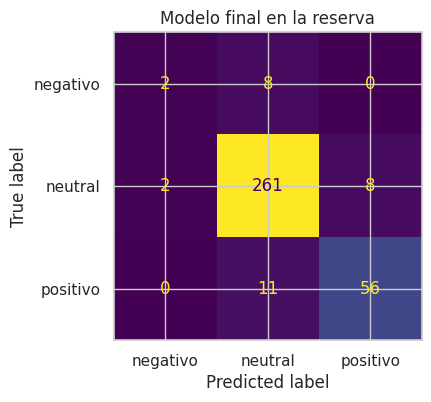

In [27]:
# Entrenar el modelo final con todo train y guardarlo
if not os.path.exists(os.path.join(MODEL_DIR, "config_inferencia.json")):
    res_final = entrenar(CFG_FINAL, train_u, None, devolver_modelo=True)
    res_final["model"].save_pretrained(MODEL_DIR)
    res_final["tokenizer"].save_pretrained(MODEL_DIR)
    with open(os.path.join(MODEL_DIR, "config_inferencia.json"), "w", encoding="utf-8") as f:
        json.dump({"max_len": CFG_FINAL["max_len"], "config": CFG_FINAL, "semilla": SEED}, f, indent=2)
    registrar({"id": "FINAL", "tipo": "modelo_final", "cambio": f"Entrenado con todo train, configuración {MEJOR_ID}",
               "checkpoint": CFG_FINAL["checkpoint"], "tiempo_s": res_final["tiempo_s"],
               "mem_gpu_mb": res_final["mem_gpu_mb"]})
    del res_final
    liberar_memoria()
else:
    print("El modelo final ya existe en", MODEL_DIR)

clf = Clasificador(MODEL_DIR)

# Evaluación única en la reserva
y_te = test_eval["label"].values
pred_te, probs_te = clf.predecir(test_eval["Comentario"].tolist())

base_final = fabrica_base()
base_final.fit(train_u["texto"].tolist(), y_all)
pred_te_base = base_final.predict(test_eval["texto"].tolist())

tabla_te = pd.concat([resumen_con_ic(y_te, pred_te, "modelo (reserva)"),
                      resumen_con_ic(y_te, pred_te_base, "baseline (reserva)")])
display(tabla_te.round(3))
print(classification_report(y_te, pred_te, target_names=NOMBRES_CLASES, digits=3, zero_division=0))
print("Negativos en la reserva:", int((y_te == 0).sum()), "(el recall de esa clase tiene un intervalo muy ancho)")

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(y_te, pred_te, display_labels=NOMBRES_CLASES, ax=ax, colorbar=False)
ax.set_title("Modelo final en la reserva")
plt.show()

m_te = metricas(y_te, pred_te)
RESUMEN["acc_reserva_modelo"] = round(float(m_te["acc"]), 4)
RESUMEN["f1_macro_reserva_modelo"] = round(float(m_te["f1_macro"]), 4)
RESUMEN["recall_neg_reserva"] = round(float(m_te["recall_neg"]), 4)
RESUMEN["acc_reserva_base"] = round(float(accuracy_score(y_te, pred_te_base)), 4)
RESUMEN["n_reserva"] = int(len(y_te))

### Análisis de errores
Se usan las predicciones fuera de fold (todas las reseñas, incluidos los 22 negativos). Primero se exportan unos 40 errores, con prioridad para los que involucran la clase negativa, y el grupo los revisa a mano. **Esta parte no se puede automatizar:** hay que leer cada reseña, asignarle una categoría y escribir una hipótesis de la causa. La rúbrica pide al menos 20 revisados.

In [28]:
oof_df = train_u.copy()
oof_df["pred"] = oof_pred
oof_df["confianza"] = oof_probs.max(1)
errores = oof_df[oof_df["pred"] != oof_df["label"]].copy()
print(len(errores), "errores de", len(oof_df), "reseñas")
print(pd.crosstab(errores["Sentimiento"], errores["pred"].map(ID2LABEL), rownames=["real"], colnames=["predicho"]))

# Prioridad para errores que involucran la clase negativa, el resto al azar
prioridad = errores[(errores["label"] == 0) | (errores["pred"] == 0)]
resto = errores.drop(prioridad.index)
muestra = pd.concat([prioridad.head(15), resto.sample(min(len(resto), 25), random_state=SEED)])
muestra = muestra[["ID", "Sitio", "municipio", "Comentario", "Sentimiento", "pred", "confianza"]].copy()
muestra["predicho"] = muestra["pred"].map(ID2LABEL)
muestra = muestra.drop(columns="pred")
muestra["categoria"] = ""
muestra["hipotesis"] = ""
muestra.to_csv(os.path.join(EXP_DIR, "errores_para_revisar.csv"), index=False)

for _, r in muestra.iterrows():
    print(f"ID {r['ID']} | {r['Sitio']} | real: {r['Sentimiento']} | predicho: {r['predicho']} | confianza {r['confianza']:.2f}")
    print("   ", r["Comentario"][:300])

58 errores de 809 reseñas
predicho  negativo  neutral  positivo
real                                 
negativo         0       11         0
neutral          0        0        22
positivo         1       24         0
ID 859 | Tripadvisor | real: negativo | predicho: neutral | confianza 0.62
    Plaza Majagual No es lugar seguro para visitar ni limpio no le hacen aseo a diario, hay días que se ve limpia y días que no. De noche es muy insegura, falta más iluminación y presencia policiva.
ID 887 | Tripadvisor | real: negativo | predicho: neutral | confianza 1.00
    Es un lugar único en Coveña pues ofrece un ecoturismo, se pueden hacer actividades al aire libre, tienes una vista hermosa en la que se ven las playas de Coveña, tiene un lago muy tranquilo. Si te gusta la naturaleza, esta puede ser una muy buena opción.
ID 863 | Tripadvisor | real: negativo | predicho: neutral | confianza 0.61
    Esperaba ver algo diferente, sin embargo no encontramos nada que llame la atención, deberían pone

In [43]:
# Aquí el grupo escribe la categoría y la hipótesis de cada error revisado.
# Formato: ID de la reseña: ("categoria", "hipótesis de la causa")
# Categorías sugeridas: ironía, negación, reseña mixta, regionalismo, error de etiqueta,
# texto muy corto, queja con etiqueta neutral por valoración del lugar, palabras pegadas, otro
CATEGORIAS = {
    859: ('queja explícita no detectada', 'Dice que no es seguro ni limpio, pero la confianza es baja (0,62). Hay solo 22 negativos y el modelo se apoya más en el nombre del lugar que en las palabras de queja.'),
    887: ('error de etiqueta por valoración del lugar', 'El texto elogia el ecoparque. La etiqueta negativa viene de la valoración del lugar, no de la reseña.'),
    863: ('queja explícita no detectada', "Expresa decepción de forma indirecta ('nada que llame la atención'), sin palabras de queja típicas. Confianza baja (0,61)."),
    851: ('queja explícita no detectada', "Texto largo y educado con quejas dispersas ('decepcionamos', 'nada interesante'). El modelo responde neutral con confianza total, lo que sugiere que asocia el estilo largo de Tripadvisor con neutral."),
    870: ('error de etiqueta por valoración del lugar', 'Reseña mixta que termina recomendando la comida típica. La etiqueta negativa viene de la valoración de la Plaza de Majagual.'),
    224: ('atajo léxico por el lugar o tema', "Solo habla de correr y aeróbicos, pero contiene 'plaza'. En la oclusión esa palabra pesó 0,95 para la clase negativa, así que el modelo usa el lugar como señal."),
    860: ('error de etiqueta por valoración del lugar', "Elogia la plaza ('excelente', 'gran variedad'). La etiqueta negativa viene de la valoración del lugar."),
    884: ('error de etiqueta por valoración del lugar', "Elogia Coveñas ('hermoso lugar', 'no dudaría en volver'). La etiqueta negativa viene del lugar."),
    873: ('error de etiqueta por valoración del lugar', "Texto positivo ('me encanta'). La etiqueta negativa viene de la valoración del lugar."),
    852: ('error de etiqueta por valoración del lugar', 'Texto positivo sobre los eventos. La etiqueta negativa viene de la valoración del lugar.'),
    865: ('reseña mixta', "Elogia los festivales pero dice que en otras épocas es 'muy solo y sin atracción'. El texto es ambiguo y el modelo se queda en neutral."),
    885: ('queja explícita no detectada', 'Señala acceso difícil, lejanía y prohibición de entrar al lago. Es una queja práctica, sin adjetivos negativos, que el modelo no asocia con la clase negativa.'),
    220: ('texto informativo sin opinión', 'Es una sugerencia sobre las fotos, sin valoración del sitio. La etiqueta positiva viene de la valoración del lugar.'),
    271: ('texto informativo sin opinión', "'Se consigue de todo' describe el sitio sin opinión. El modelo lo manda a positivo por ser corto y de estilo Foursquare."),
    210: ('error de etiqueta por valoración del lugar', "Es una queja clara ('pésimo', 'nada especial') pero la etiqueta es positiva por la valoración del lugar. El modelo no predijo positivo, así que en este caso se acerca más al texto."),
    284: ('error de etiqueta por valoración del lugar', "'Bien acogedor' es positivo. La etiqueta neutral viene de la valoración del lugar (6,4 a 6,9 en Foursquare)."),
    137: ('idioma o registro informal', 'Mayúsculas sostenidas y exclamaciones. Confianza baja (0,56). Es un formato poco frecuente en train, hipótesis sin comprobar.'),
    291: ('texto informativo sin opinión', 'Lista de marcas sin opinión. El modelo predice positivo por ser corto y de estilo Foursquare.'),
    1297: ('error de etiqueta por valoración del lugar', "Texto muy positivo con errores ortográficos ('esperiencia', 'expectacular'). En Tripadvisor ninguna reseña es positiva por regla, así que el neutral viene de la etiqueta. El modelo acertó con el texto."),
    241: ('atajo por estilo o sitio', 'Reseña larga y bien escrita de Foursquare. Se parece al estilo de Tripadvisor (neutral) y el modelo responde neutral con confianza 1,00.'),
    279: ('error de etiqueta por valoración del lugar', "'Postres deliciosos' es positivo. La etiqueta neutral viene de la valoración del lugar."),
    138: ('texto informativo sin opinión', 'Anuncia una apertura, sin opinión. La etiqueta positiva viene de la valoración del lugar.'),
    54: ('idioma o registro informal', 'Está en inglés y lleva emoji. Hay muy pocos textos en inglés en train.'),
    94: ('texto informativo sin opinión', 'Describe un servicio de Wi-Fi público, sin opinión. La etiqueta positiva viene del lugar.'),
    60: ('idioma o registro informal', "Usa la abreviatura 'flia'. Vocabulario poco visto, y el modelo cae en la clase mayoritaria (hipótesis)."),
    240: ('idioma o registro informal', "Mezcla inglés y construcciones incorrectas ('is not fast foot'). Hay muy pocos textos en inglés en train."),
    68: ('atajo léxico por el lugar o tema', "'Coveñas' aparece sobre todo en reseñas neutrales (250 de 293), así que el nombre empuja hacia neutral aunque el texto sea elogioso."),
    298: ('error de etiqueta por valoración del lugar', "'Disfruten la amable atención' es positivo. La etiqueta neutral viene de la valoración del lugar."),
    297: ('error de etiqueta por valoración del lugar', "'Los mejores helados' es positivo. La etiqueta neutral viene de la valoración del lugar."),
    290: ('error de etiqueta por valoración del lugar', "'Super chevereee' es positivo (regionalismo con letras alargadas). La etiqueta neutral viene del lugar y el modelo acertó con el texto."),
    269: ('reseña mixta', 'Elogia la comida y critica la demora de 25 a 35 minutos. La etiqueta neutral es razonable y el modelo se queda con lo positivo.'),
    317: ('error de etiqueta por valoración del lugar', "'Wrap Lomo deli!' con emoji es positivo. La etiqueta neutral viene de la valoración del lugar."),
    318: ('error de etiqueta por valoración del lugar', "'Aritos de cebolla #FTW' es positivo (jerga en inglés). La etiqueta neutral viene de la valoración del lugar."),
    182: ('atajo por estilo o sitio', 'Reseña larga y bien escrita de Foursquare, sin palabras pegadas. Se parece al estilo de Tripadvisor y el modelo responde neutral con confianza 1,00.'),
    47: ('atajo léxico por el lugar o tema', 'Habla de olas y playa. Las reseñas de playas son mayoritariamente neutrales, y el modelo parece asociar el tema con neutral (hipótesis).'),
    200: ('atajo por estilo o sitio', 'Reseña larga y bien escrita de Foursquare. El modelo responde neutral con confianza 0,99, igual que en otras reseñas largas.'),
    190: ('atajo por estilo o sitio', 'Texto corto y positivo, pero sin las marcas típicas de Foursquare (palabras pegadas). El modelo no tiene pistas de estilo y cae en neutral (hipótesis).'),
}


if len(CATEGORIAS) == 0:
    print("Falta llenar CATEGORIAS con al menos 20 errores revisados")
else:
    rev = muestra[muestra["ID"].isin(CATEGORIAS.keys())].copy()
    rev["categoria"] = rev["ID"].map(lambda i: CATEGORIAS[i][0])
    rev["hipotesis"] = rev["ID"].map(lambda i: CATEGORIAS[i][1])
    print("Errores revisados:", len(rev), "(mínimo exigido: 20)")
    display(rev["categoria"].value_counts().rename("n").to_frame())
    display(rev[["ID", "Sentimiento", "predicho", "categoria", "hipotesis"]])
    rev.to_csv(os.path.join(EXP_DIR, "errores_categorizados.csv"), index=False)

Errores revisados: 37 (mínimo exigido: 20)


,n
categoria,
error de etiqueta por valoración del lugar,15
texto informativo sin opinión,5
queja explícita no detectada,4
atajo por estilo o sitio,4
idioma o registro informal,4
atajo léxico por el lugar o tema,3
reseña mixta,2


,ID,Sentimiento,predicho,categoria,hipotesis
35,859,negativo,neutral,queja explícita no detectada,"Dice que no es seguro ni limpio, pero la confianza es baja (0,62). Hay solo 22 negativos y el modelo se apoya más en el nombre del lugar que en las palabras..."
42,887,negativo,neutral,error de etiqueta por valoración del lugar,"El texto elogia el ecoparque. La etiqueta negativa viene de la valoración del lugar, no de la reseña."
164,863,negativo,neutral,queja explícita no detectada,"Expresa decepción de forma indirecta ('nada que llame la atención'), sin palabras de queja típicas. Confianza baja (0,61)."
187,851,negativo,neutral,queja explícita no detectada,"Texto largo y educado con quejas dispersas ('decepcionamos', 'nada interesante'). El modelo responde neutral con confianza total, lo que sugiere que asocia ..."
337,870,negativo,neutral,error de etiqueta por valoración del lugar,Reseña mixta que termina recomendando la comida típica. La etiqueta negativa viene de la valoración de la Plaza de Majagual.
359,224,positivo,negativo,atajo léxico por el lugar o tema,"Solo habla de correr y aeróbicos, pero contiene 'plaza'. En la oclusión esa palabra pesó 0,95 para la clase negativa, así que el modelo usa el lugar como se..."
445,860,negativo,neutral,error de etiqueta por valoración del lugar,"Elogia la plaza ('excelente', 'gran variedad'). La etiqueta negativa viene de la valoración del lugar."
568,884,negativo,neutral,error de etiqueta por valoración del lugar,"Elogia Coveñas ('hermoso lugar', 'no dudaría en volver'). La etiqueta negativa viene del lugar."
669,873,negativo,neutral,error de etiqueta por valoración del lugar,Texto positivo ('me encanta'). La etiqueta negativa viene de la valoración del lugar.
713,852,negativo,neutral,error de etiqueta por valoración del lugar,Texto positivo sobre los eventos. La etiqueta negativa viene de la valoración del lugar.


### Robustez
Se evalúa el modelo final en la reserva con textos alterados de forma controlada, con semilla fija:

- **Ortografía:** se intercambian dos letras vecinas en el 15 % de las palabras.
- **Sin tildes ni mayúsculas:** proxy de escritura informal o de variantes de registro.
- **Palabras pegadas:** se unen palabras vecinas, que es el defecto que ya trae la extracción de datos.
- **Textos largos:** se compara la accuracy de las reseñas de más de 128 tokens con las demás.

In [30]:
def con_errores_ortograficos(t, rng, p=0.15):
    palabras = t.split()
    for i, w in enumerate(palabras):
        if len(w) > 3 and rng.random() < p:
            j = int(rng.integers(0, len(w) - 1))
            palabras[i] = w[:j] + w[j + 1] + w[j] + w[j + 2:]
    return " ".join(palabras)

def sin_tildes_ni_mayusculas(t, rng=None):
    base = unicodedata.normalize("NFD", t)
    return "".join(c for c in base if unicodedata.category(c) != "Mn").lower()

def con_palabras_pegadas(t, rng, p=0.2):
    salida = []
    for w in t.split():
        if salida and rng.random() < p:
            salida[-1] += w
        else:
            salida.append(w)
    return " ".join(salida)

def perturbar(textos, fn, semilla=SEED):
    rng = np.random.default_rng(semilla)
    return [fn(t, rng) for t in textos]

originales = test_eval["Comentario"].tolist()
pert = {
    "ortografía": perturbar(originales, con_errores_ortograficos),
    "sin tildes ni mayúsculas": perturbar(originales, sin_tildes_ni_mayusculas),
    "palabras pegadas": perturbar(originales, con_palabras_pegadas),
}

filas = [{"variante": "original", "acc": accuracy_score(y_te, pred_te), "f1_macro": metricas(y_te, pred_te)["f1_macro"]}]
pred_pert = {}
for nombre, textos in pert.items():
    p, _ = clf.predecir(textos)
    pred_pert[nombre] = p
    filas.append({"variante": nombre, "acc": accuracy_score(y_te, p), "f1_macro": metricas(y_te, p)["f1_macro"]})
tabla_rob = pd.DataFrame(filas)
tabla_rob["caída de accuracy"] = tabla_rob["acc"].iloc[0] - tabla_rob["acc"]
display(tabla_rob.round(3))

# Textos largos frente al resto
n_tok = np.array([len(x) for x in tokenizar(clf.tokenizer, [limpiar(t) for t in originales], 512)])
largo = n_tok > 128
print(f"Reseñas largas (más de 128 tokens): n={largo.sum()}, accuracy={accuracy_score(y_te[largo], pred_te[largo]):.3f}")
print(f"Reseñas cortas o medias: n={(~largo).sum()}, accuracy={accuracy_score(y_te[~largo], pred_te[~largo]):.3f}")
RESUMEN["robustez_caida_acc"] = {r["variante"]: round(float(r["caída de accuracy"]), 4) for _, r in tabla_rob.iterrows()}

,variante,acc,f1_macro,caída de accuracy
0,original,0.917,0.696,0.000
1,ortografía,0.874,0.703,0.043
2,sin tildes ni mayúsculas,0.920,0.796,-0.003
3,palabras pegadas,0.443,0.297,0.474


Reseñas largas (más de 128 tokens): n=29, accuracy=1.000
Reseñas cortas o medias: n=319, accuracy=0.909


### Explicabilidad
Se usa **oclusión por palabra**: se quita cada palabra del texto y se mide cuánto baja la probabilidad de la clase predicha. Si baja mucho, esa palabra empujaba la predicción. Es un método de atribución sencillo y no necesita librerías extra. Si `captum` está instalado, también se calcula Integrated Gradients sobre uno de los ejemplos.

Advertencia: estas atribuciones muestran sensibilidad del modelo a ciertas palabras, no una explicación causal de por qué decide así. La atención de un Transformer tampoco equivale a una explicación.

In [31]:
def oclusion(clf, texto, clase=None):
    palabras = texto.split()
    base = clf.probs([texto])[0]
    clase = int(base.argmax()) if clase is None else clase
    variantes = [" ".join(palabras[:i] + palabras[i + 1:]) for i in range(len(palabras))]
    p = clf.probs(variantes)[:, clase]
    return clase, base, sorted(zip(palabras, base[clase] - p), key=lambda x: -x[1])

# Un acierto por clase y dos errores, con textos cortos para que se lean bien
cortos = test_eval["Comentario"].str.split().str.len() <= 45
ejemplos = []
for c in [0, 1, 2]:
    cand = np.where((y_te == c) & (pred_te == c) & cortos.values)[0]
    if len(cand):
        ejemplos.append(("acierto", cand[0]))
err_idx = np.where((y_te != pred_te) & cortos.values)[0]
ejemplos += [("error", i) for i in err_idx[:2]]

for tipo, i in ejemplos:
    texto = test_eval.loc[i, "Comentario"]
    clase, base, imp = oclusion(clf, texto)
    print(f"[{tipo}] real: {ID2LABEL[int(y_te[i])]} | predicho: {ID2LABEL[clase]} | probabilidad {base[clase]:.2f}")
    print("   ", texto[:250])
    print("    palabras con más peso:", [(w, round(float(v), 2)) for w, v in imp[:5]])

[acierto] real: negativo | predicho: negativo | probabilidad 0.97
    Una plaza muy típica de ciudades intermedias colombianas, vale la pena visitarla en las tardes de fin de semana para ver el movimiento usual de la ciudad y disfrutar del atardecer sabanero.
    palabras con más peso: [('plaza', 0.95), ('Una', 0.14), ('sabanero.', 0.07), ('movimiento', 0.01), ('usual', 0.0)]
[acierto] real: neutral | predicho: neutral | probabilidad 1.00
    Recomiendo las pastas con tocineta, son realmente buenas, a los crepes también vale la pena resaltarlos. El servicio es algo demorado, pero la amabilidad e interés de la dueña le dan puntos extra.
    palabras con más peso: [('e', 0.0), ('pena', 0.0), ('El', 0.0), ('realmente', 0.0), ('interés', 0.0)]
[acierto] real: positivo | predicho: positivo | probabilidad 0.99
    Muy bueno deli .
    palabras con más peso: [('deli', 0.03), ('bueno', 0.0), ('.', -0.0), ('Muy', -0.0)]
[error] real: positivo | predicho: neutral | probabilidad 1.00
    Un lugar

In [32]:
# Integrated Gradients sobre un ejemplo (solo si captum está instalado)
if LayerIntegratedGradients is None or len(ejemplos) == 0:
    print("captum no está instalado, se omite Integrated Gradients")
else:
    try:
        texto = test_eval.loc[ejemplos[0][1], "Comentario"]
        enc = clf.tokenizer(limpiar(texto), return_tensors="pt", truncation=True, max_length=clf.max_len).to(clf.device)
        pred_c = int(clf.probs([texto])[0].argmax())

        def fwd(ids, mask):
            return clf.model(input_ids=ids, attention_mask=mask).logits

        lig = LayerIntegratedGradients(fwd, clf.model.get_input_embeddings())
        base_ids = torch.full_like(enc["input_ids"], clf.tokenizer.pad_token_id)
        base_ids[:, 0] = enc["input_ids"][:, 0]
        base_ids[:, -1] = enc["input_ids"][:, -1]
        atr = lig.attribute(enc["input_ids"], baselines=base_ids, additional_forward_args=(enc["attention_mask"],),
                            target=pred_c, n_steps=30)
        puntos = atr.sum(-1).squeeze(0)
        puntos = (puntos / puntos.abs().max()).detach().cpu().numpy()
        toks = clf.tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
        print("Texto:", texto[:200])
        print(sorted(zip(toks, puntos.round(2)), key=lambda x: -abs(x[1]))[:8])
    except Exception as e:
        print("No se pudo calcular Integrated Gradients:", repr(e)[:200])

captum no está instalado, se omite Integrated Gradients


### Sesgos y privacidad
Se compara el desempeño por grupos usando las predicciones fuera de fold: sitio, municipio y longitud del texto. Los grupos con pocos casos tienen métricas muy inestables y se marcan con su tamaño. Sobre privacidad, la búsqueda de correos y teléfonos en la Fase 1 no encontró datos personales, y las reseñas se tratan como texto público de las plataformas, sin identificar autores.

In [33]:
oof_df["n_tokens"] = [len(x) for x in tokenizar(tok_eda, oof_df["texto"].tolist(), 512)]
oof_df["rango_longitud"] = pd.cut(oof_df["n_tokens"], [0, 16, 32, 64, 128, 1000],
                                  labels=["1 a 16", "17 a 32", "33 a 64", "65 a 128", "más de 128"])

def tabla_por_grupo(df, col):
    filas = []
    for g, d in df.groupby(col, observed=True):
        negativos = int((d["label"] == 0).sum())
        filas.append({col: g, "n": len(d), "negativos": negativos,
                      "accuracy": accuracy_score(d["label"], d["pred"]),
                      "recall_neg": metricas(d["label"].values, d["pred"].values)["recall_neg"] if negativos else np.nan,
                      "confianza_media": d["confianza"].mean()})
    return pd.DataFrame(filas).round(3)

for col in ["Sitio", "municipio", "rango_longitud"]:
    display(tabla_por_grupo(oof_df, col))

# Cuánto del acierto depende del sitio: el modelo nunca ve la columna Sitio, pero puede inferirla del estilo
print("Pred. positiva en Foursquare:", round((oof_df[oof_df["Sitio"] == "Foursquare"]["pred"] == 2).mean(), 3))
print("Pred. positiva en Tripadvisor:", round((oof_df[oof_df["Sitio"] == "Tripadvisor"]["pred"] == 2).mean(), 3))

,Sitio,n,negativos,accuracy,recall_neg,confianza_media
0,Foursquare,199,0,0.779,NaN,0.966
1,Tripadvisor,610,22,0.977,0.5,0.991


,municipio,n,negativos,accuracy,recall_neg,confianza_media
0,Coloso,4,0,1.000,NaN,0.998
1,Corozal,10,0,0.800,NaN,0.979
2,Coveñas,292,3,0.969,0.000,0.993
3,San Onofre,277,0,0.989,NaN,0.997
4,Santiago de Tolú,29,0,1.000,NaN,0.988
5,Sincelejo,189,19,0.772,0.579,0.956
6,Sincé,8,0,0.875,NaN,0.910


,rango_longitud,n,negativos,accuracy,recall_neg,confianza_media
0,1 a 16,111,0,0.748,NaN,0.956
1,17 a 32,213,10,0.925,0.600,0.980
2,33 a 64,286,11,0.958,0.455,0.990
3,65 a 128,132,1,0.992,0.000,0.997
4,más de 128,67,0,0.985,NaN,0.998


Pred. positiva en Foursquare: 0.759
Pred. positiva en Tripadvisor: 0.005


La decisión explícita frente a los criterios de éxito se toma al final de la Fase 5, cuando ya se midió también el costo de inferencia.

## Fase 5. Despliegue

### Pipeline de inferencia y archivo de envío
El script `src/inferencia.py` es independiente del notebook: solo necesita la carpeta del modelo guardado y un CSV con la columna `Comentario`. Genera el archivo de envío con las columnas `ID` y `Sentimiento` (0, 1 o 2). Aquí se escribe el script, se ejecuta como un proceso aparte sobre `submission.csv` y se comprueba que el archivo cumple el formato de la competencia y que coincide con lo que predice el modelo dentro del notebook.

In [34]:
SCRIPT_INFERENCIA = r'''
# Inferencia independiente para Traveler Insights UPTC 2026
# Uso: python inferencia.py --modelo modelo_final --entrada submission.csv --salida submission_envio.csv
import argparse
import json
import os
import re

import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification


def limpiar(t):
    t = re.sub(r"https?://\S+|www\.\S+", " ", str(t))
    return re.sub(r"\s+", " ", t).strip()


class Clasificador:
    def __init__(self, ruta, device=None):
        self.device = torch.device(device) if device else torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.tokenizer = AutoTokenizer.from_pretrained(ruta)
        self.model = AutoModelForSequenceClassification.from_pretrained(ruta).to(self.device).eval()
        with open(os.path.join(ruta, "config_inferencia.json"), encoding="utf-8") as f:
            self.max_len = json.load(f)["max_len"]

    @torch.no_grad()
    def probs(self, textos, batch_size=64):
        textos = [limpiar(t) for t in textos]
        ids = self.tokenizer(textos, truncation=True, max_length=self.max_len)["input_ids"]
        orden = np.argsort([len(x) for x in ids])
        pad = self.tokenizer.pad_token_id
        salida = np.zeros((len(ids), self.model.config.num_labels), dtype=np.float32)
        for i in range(0, len(orden), batch_size):
            idx = orden[i:i + batch_size]
            largo = max(len(ids[j]) for j in idx)
            x = torch.full((len(idx), largo), pad, dtype=torch.long)
            m = torch.zeros((len(idx), largo), dtype=torch.long)
            for r, j in enumerate(idx):
                x[r, :len(ids[j])] = torch.tensor(ids[j])
                m[r, :len(ids[j])] = 1
            logits = self.model(input_ids=x.to(self.device), attention_mask=m.to(self.device)).logits
            salida[idx] = torch.softmax(logits.float(), dim=-1).cpu().numpy()
        return salida


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--modelo", required=True)
    ap.add_argument("--entrada", required=True)
    ap.add_argument("--salida", required=True)
    a = ap.parse_args()
    df = pd.read_csv(a.entrada)
    clf = Clasificador(a.modelo)
    p = clf.probs(df["Comentario"].tolist())
    pd.DataFrame({"ID": df["ID"], "Sentimiento": p.argmax(1)}).to_csv(a.salida, index=False)
    print("Archivo escrito:", a.salida, "con", len(df), "filas")


if __name__ == "__main__":
    main()
'''

ruta_script = os.path.join(SRC_DIR, "inferencia.py")
with open(ruta_script, "w", encoding="utf-8") as f:
    f.write(SCRIPT_INFERENCIA.strip() + "\n")

# Ejecutar el script como proceso aparte sobre el archivo a predecir
SUB_OUT = os.path.join(WORK_DIR, "submission.csv")
proc = subprocess.run([sys.executable, ruta_script, "--modelo", MODEL_DIR,
                       "--entrada", SAMPLE_SUB_PATH, "--salida", SUB_OUT],
                      capture_output=True, text=True)
print(proc.stdout.strip() or proc.stderr[-500:])
assert proc.returncode == 0, "El script de inferencia falló"

# Comprobaciones de formato
envio = pd.read_csv(SUB_OUT)
assert list(envio.columns) == ["ID", "Sentimiento"], "Las columnas deben ser ID y Sentimiento"
assert len(envio) == len(sub), "Faltan o sobran filas"
assert envio["ID"].is_unique and set(envio["ID"]) == set(sub["ID"]), "Los ID no coinciden con el archivo de la competencia"
assert envio["Sentimiento"].isin([0, 1, 2]).all(), "Hay clases fuera de 0, 1 y 2"
print("Formato del envío correcto:", envio.shape)

# El script y el modelo dentro del notebook deben dar lo mismo
pred_nb, probs_sub = clf.predecir(sub["Comentario"].tolist())
coincide = float((pred_nb == envio["Sentimiento"].values).mean())
print("Coincidencia entre el script y el notebook:", round(coincide, 4))
print(envio["Sentimiento"].map(ID2LABEL).value_counts(normalize=True).round(3))
RESUMEN["coincidencia_script_notebook"] = round(coincide, 4)
envio.head()

Archivo escrito: /kaggle/working/submission.csv con 129 filas
Formato del envío correcto: (129, 2)
Coincidencia entre el script y el notebook: 1.0
Sentimiento
neutral     0.752
positivo    0.233
negativo    0.016
Name: proportion, dtype: float64


,ID,Sentimiento
0,980,1
1,1249,1
2,260,1
3,459,1
4,309,2


### Demo
Una función que clasifica una reseña nueva y devuelve la clase con las probabilidades. Abajo hay cuatro reseñas de ejemplo escritas para la prueba. Si se quiere una interfaz web, el bloque comentado de Gradio la levanta.

In [35]:
def clasificar_resena(texto):
    pred, p = clf.predecir([texto])
    return ID2LABEL[int(pred[0])], {ID2LABEL[i]: round(float(p[0][i]), 3) for i in range(3)}

ejemplos_demo = [
    "Una playa preciosa, el agua tranquila y la atención de los guías fue excelente. Volveremos pronto.",
    "Todo muy sucio y con poca seguridad por la noche, no lo recomiendo.",
    "Es un lugar normal, nada del otro mundo, la comida estuvo bien.",
    "Pagamos bastante por una comida regular y el servicio fue lento.",
]
for t in ejemplos_demo:
    clase, probs = clasificar_resena(t)
    print(t)
    print("   ->", clase, probs)

# Interfaz web opcional, descomentar para usarla
# if gr is not None:
#     demo = gr.Interface(fn=lambda t: clasificar_resena(t)[1],
#                         inputs=gr.Textbox(lines=4, label="Reseña"),
#                         outputs=gr.Label(num_top_classes=3),
#                         title="Sentimiento de reseñas turísticas")
#     demo.launch()

Una playa preciosa, el agua tranquila y la atención de los guías fue excelente. Volveremos pronto.
   -> neutral {'negativo': 0.001, 'neutral': 0.999, 'positivo': 0.0}
Todo muy sucio y con poca seguridad por la noche, no lo recomiendo.
   -> positivo {'negativo': 0.003, 'neutral': 0.006, 'positivo': 0.991}
Es un lugar normal, nada del otro mundo, la comida estuvo bien.
   -> neutral {'negativo': 0.015, 'neutral': 0.948, 'positivo': 0.037}
Pagamos bastante por una comida regular y el servicio fue lento.
   -> neutral {'negativo': 0.028, 'neutral': 0.677, 'positivo': 0.295}


### Costo de inferencia
Se mide la latencia por reseña (de una en una), el rendimiento por lotes, el tamaño del modelo y el pico de memoria de GPU. También se mide en CPU, que es lo que tendría un operador sin GPU. Opcionalmente se prueba la cuantización dinámica a 8 bits, que reduce el tamaño y puede acelerar la CPU a cambio de algo de precisión.

In [36]:
def sincronizar(dev):
    if dev.type == "cuda":
        torch.cuda.synchronize()

def medir_latencia(c, textos, n=100):
    for t in textos[:5]:
        c.probs([t])
    sincronizar(c.device)
    ts = []
    for t in textos[:n]:
        t0 = time.perf_counter()
        c.probs([t])
        sincronizar(c.device)
        ts.append((time.perf_counter() - t0) * 1000)
    return float(np.median(ts)), float(np.percentile(ts, 95))

params = sum(p.numel() for p in clf.model.parameters())
tam_mb = sum(os.path.getsize(os.path.join(MODEL_DIR, f)) for f in os.listdir(MODEL_DIR)) / 2**20
print(f"Parámetros: {params / 1e6:.1f} M | carpeta del modelo guardado: {tam_mb:.0f} MB")
RESUMEN["params_millones"] = round(params / 1e6, 1)
RESUMEN["tamano_modelo_mb"] = round(tam_mb)

textos_lat = test_eval["Comentario"].tolist()
if DEVICE.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
    mediana, p95 = medir_latencia(clf, textos_lat, 100)
    t0 = time.perf_counter()
    clf.probs(textos_lat)
    sincronizar(DEVICE)
    por_seg = len(textos_lat) / (time.perf_counter() - t0)
    mem_pico = torch.cuda.max_memory_allocated() / 2**20
    print(f"GPU: latencia mediana {mediana:.1f} ms, p95 {p95:.1f} ms | {por_seg:.0f} reseñas por segundo en lote | memoria pico {mem_pico:.0f} MB")
    RESUMEN.update({"latencia_gpu_ms": round(mediana, 1), "latencia_gpu_p95_ms": round(p95, 1),
                    "resenas_por_segundo_gpu": round(por_seg), "mem_pico_mb": round(mem_pico)})
else:
    print("No hay GPU, se omite la medición en GPU")

clf_cpu = Clasificador(MODEL_DIR, device=torch.device("cpu"))
med_cpu, p95_cpu = medir_latencia(clf_cpu, textos_lat, 30)
print(f"CPU: latencia mediana {med_cpu:.1f} ms, p95 {p95_cpu:.1f} ms")
RESUMEN["latencia_cpu_ms"] = round(med_cpu, 1)

Parámetros: 109.9 M | carpeta del modelo guardado: 420 MB
GPU: latencia mediana 11.0 ms, p95 12.1 ms | 288 reseñas por segundo en lote | memoria pico 704 MB


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

CPU: latencia mediana 88.4 ms, p95 155.0 ms


In [37]:
# Compresión opcional: cuantización dinámica a 8 bits en CPU
try:
    modelo_q = torch.ao.quantization.quantize_dynamic(copy.deepcopy(clf_cpu.model), {nn.Linear}, dtype=torch.qint8)
    clf_q = copy.copy(clf_cpu)
    clf_q.model = modelo_q
    pred_q, _ = clf_q.predecir(test_eval["Comentario"].tolist())
    lat_q, _ = medir_latencia(clf_q, textos_lat, 30)
    ruta_tmp = os.path.join(WORK_DIR, "tmp_cuantizado.pt")
    torch.save(modelo_q.state_dict(), ruta_tmp)
    tam_q = os.path.getsize(ruta_tmp) / 2**20
    os.remove(ruta_tmp)
    acc_q = accuracy_score(y_te, pred_q)
    print(f"Cuantizado: accuracy {acc_q:.3f} (sin cuantizar {RESUMEN['acc_reserva_modelo']:.3f}) | "
          f"latencia CPU {lat_q:.1f} ms (antes {med_cpu:.1f} ms) | tamaño {tam_q:.0f} MB")
    RESUMEN.update({"cuantizado_acc_reserva": round(float(acc_q), 4), "cuantizado_latencia_cpu_ms": round(lat_q, 1),
                    "cuantizado_tamano_mb": round(tam_q)})
except Exception as e:
    print("No se pudo cuantizar:", repr(e)[:200])

Cuantizado: accuracy 0.920 (sin cuantizar 0.917) | latencia CPU 53.6 ms (antes 88.4 ms) | tamaño 174 MB


### Decisión frente a los criterios de éxito
Se contrastan los criterios definidos en la Fase 1 con lo medido. Los umbrales están en la primera línea de la celda para poder ajustarlos si el grupo los redefine, siempre antes de ver los resultados finales.

In [38]:
UMBRAL_MARGEN = 0.02
UMBRAL_LATENCIA_MS = 100
MEMORIA_T4_MB = 15000

criterios = [
    ("ML: la accuracy en CV supera al baseline en al menos 0,02",
     RESUMEN["dif_acc_modelo_menos_base"] >= UMBRAL_MARGEN,
     f"diferencia de {RESUMEN['dif_acc_modelo_menos_base']:.3f} (IC 95%: {RESUMEN['dif_acc_ic'][0]:.3f} a {RESUMEN['dif_acc_ic'][1]:.3f})"),
    ("ML: el intervalo de la diferencia no incluye el cero",
     RESUMEN["dif_acc_ic"][0] > 0,
     f"límite inferior {RESUMEN['dif_acc_ic'][0]:.3f}"),
    ("Negocio: recall de negativos en CV igual o mayor al del baseline",
     RESUMEN["recall_neg_cv"] >= RESUMEN["recall_neg_cv_base"],
     f"modelo {RESUMEN['recall_neg_cv']:.3f} frente a baseline {RESUMEN['recall_neg_cv_base']:.3f}"),
    ("Económico: latencia por reseña menor a 100 ms en GPU",
     RESUMEN.get("latencia_gpu_ms", 1e9) < UMBRAL_LATENCIA_MS,
     f"{RESUMEN.get('latencia_gpu_ms', 'sin GPU')} ms"),
    ("Económico: el modelo cabe en una T4",
     RESUMEN.get("mem_pico_mb", 1e9) < MEMORIA_T4_MB,
     f"{RESUMEN.get('mem_pico_mb', 'sin GPU')} MB de pico"),
]
for nombre, ok, detalle in criterios:
    print(("SÍ " if ok else "NO ") + nombre + " | " + detalle)

cumple = all(ok for _, ok, _ in criterios)
RESUMEN["cumple_criterios"] = bool(cumple)
print("\nDecisión:", "el modelo cumple los criterios de éxito" if cumple else "el modelo NO cumple todos los criterios, ver cuáles fallan arriba")

SÍ ML: la accuracy en CV supera al baseline en al menos 0,02 | diferencia de 0.031 (IC 95%: 0.011 a 0.052)
SÍ ML: el intervalo de la diferencia no incluye el cero | límite inferior 0.011
SÍ Negocio: recall de negativos en CV igual o mayor al del baseline | modelo 0.500 frente a baseline 0.318
SÍ Económico: latencia por reseña menor a 100 ms en GPU | 11.0 ms
SÍ Económico: el modelo cabe en una T4 | 704 MB de pico

Decisión: el modelo cumple los criterios de éxito


## Fase 6. Monitoreo y mantenimiento

### Qué se monitorearía
Una vez en uso, el modelo no recibe etiquetas, así que se vigilan señales indirectas y se revisa una muestra pequeña con etiqueta de forma periódica.

| Señal | Para qué sirve | Cómo se calcula |
|---|---|---|
| Distribución de clases predichas | Detecta cambios en el tipo de reseñas o en el modelo | Porcentaje de negativo, neutral y positivo por semana |
| Confianza media | Una caída indica textos que el modelo no reconoce | Media de la probabilidad máxima |
| Longitud de los textos | Detecta una plataforma o un formato nuevo | Mediana de tokens y prueba KS contra la referencia |
| Vocabulario nuevo | Detecta jerga o escritura que el tokenizer no cubre | Porcentaje de textos con token desconocido |
| Accuracy en muestra etiquetada | La única señal directa de calidad | 50 reseñas etiquetadas a mano cada mes |

### Simulación de monitoreo
Se calculan esas señales sobre la reserva, sobre el conjunto a predecir y sobre tres variantes con cambio de distribución: texto con ruido, solo reseñas de Foursquare y solo reseñas largas.

In [39]:
def reporte_monitoreo(c, textos, nombre, ref_largo=None):
    limpios = [limpiar(t) for t in textos]
    p = c.probs(limpios)
    pred = p.argmax(1)
    ids = tokenizar(c.tokenizer, limpios, 512)
    largo = np.array([len(x) for x in ids])
    fila = {
        "conjunto": nombre, "n": len(limpios),
        "%negativo": 100 * np.mean(pred == 0), "%neutral": 100 * np.mean(pred == 1), "%positivo": 100 * np.mean(pred == 2),
        "confianza_media": float(p.max(1).mean()), "tokens_mediana": float(np.median(largo)),
        "%con_token_desconocido": 100 * np.mean([c.tokenizer.unk_token_id in x for x in ids]),
    }
    if ref_largo is not None:
        fila["KS_longitud"] = float(stats.ks_2samp(largo, ref_largo).statistic)
    return fila, largo

fila_ref, largo_ref = reporte_monitoreo(clf, originales, "referencia (reserva)")
ruido = perturbar(perturbar(originales, con_errores_ortograficos), con_palabras_pegadas)
es_largo = [t for t, l in zip(originales, largo_ref) if l > 128]
conjuntos = {
    "conjunto a predecir": sub["Comentario"].tolist(),
    "reserva con ruido": ruido,
    "solo Foursquare": test_eval[test_eval["Sitio"] == "Foursquare"]["Comentario"].tolist(),
    "solo reseñas largas": es_largo,
}
filas = [fila_ref]
for nombre, textos in conjuntos.items():
    if len(textos) == 0:
        print("Sin textos para", nombre)
        continue
    f, _ = reporte_monitoreo(clf, textos, nombre, ref_largo=largo_ref)
    filas.append(f)
tabla_mon = pd.DataFrame(filas).round(3)
display(tabla_mon)
tabla_mon.to_csv(os.path.join(EXP_DIR, "monitoreo_simulado.csv"), index=False)

,conjunto,n,%negativo,%neutral,%positivo,confianza_media,tokens_mediana,%con_token_desconocido,KS_longitud
0,referencia (reserva),348,1.149,80.460,18.391,0.984,38.0,4.310,NaN
1,conjunto a predecir,129,1.550,75.194,23.256,0.986,36.0,5.426,0.063
2,reserva con ruido,348,0.000,17.241,82.759,0.960,44.5,4.310,0.095
3,solo Foursquare,90,1.111,28.889,70.000,0.957,16.0,5.556,0.564
4,solo reseñas largas,29,0.000,100.000,0.000,0.999,168.0,6.897,0.917


### Simulación de drift
Para medir la degradación con cambio real de distribución se reentrena el modelo dejando afuera un grupo y se prueba justo en ese grupo. Se comparan dos escenarios: un **destino nuevo** (Coveñas, que no se ve en el entrenamiento) y una **época nueva** (reseñas de 2018 en adelante, entrenando solo con años anteriores). La referencia es la accuracy que el mismo modelo tiene en esas reseñas con la validación cruzada normal, donde sí vio reseñas parecidas. Se descartó dejar afuera Sincelejo porque tiene 19 de los 22 negativos y el modelo quedaría sin ejemplos de esa clase.

In [40]:
train_u["anio"] = train_u["Fecha"].str.extract(r"(19\d{2}|20\d{2})")[0].astype(float)

def simular_drift(nombre, mascara):
    tr = train_u[~mascara].reset_index(drop=True)
    te = train_u[mascara].reset_index(drop=True)
    print(f"\n{nombre}: entrenamiento {len(tr)}, prueba {len(te)}, negativos en entrenamiento {(tr['label'] == 0).sum()}, en prueba {(te['label'] == 0).sum()}")
    res = entrenar(CFG_FINAL, tr, te)
    pred_t = res["probs_val"].argmax(1)
    mod = fabrica_base()
    mod.fit(tr["texto"].tolist(), tr["label"].values)
    pred_b = mod.predict(te["texto"].tolist())
    y = te["label"].values
    hay_neg = (y == 0).sum() > 0
    m_ref = metricas(y, oof_pred[mascara.values])
    m_dri = metricas(y, pred_t)
    return {
        "escenario": nombre, "n_prueba": len(te), "negativos_prueba": int((y == 0).sum()),
        "acc_modelo_referencia": m_ref["acc"], "acc_modelo_drift": m_dri["acc"],
        "caida_modelo": m_ref["acc"] - m_dri["acc"],
        "acc_baseline_referencia": accuracy_score(y, oof_base[mascara.values]),
        "acc_baseline_drift": accuracy_score(y, pred_b),
        "recall_neg_referencia": m_ref["recall_neg"] if hay_neg else np.nan,
        "recall_neg_drift": m_dri["recall_neg"] if hay_neg else np.nan,
    }

ESCENARIOS = {
    "Destino nuevo: Coveñas": train_u["municipio"] == "Coveñas",
    "Época nueva: 2018 en adelante": train_u["anio"] >= 2018,
}
tabla_drift = pd.DataFrame([simular_drift(n, m) for n, m in ESCENARIOS.items()]).round(3)
display(tabla_drift.T)
tabla_drift.to_csv(os.path.join(EXP_DIR, "drift_simulado.csv"), index=False)
RESUMEN["drift"] = tabla_drift.set_index("escenario")[["acc_modelo_referencia", "acc_modelo_drift", "caida_modelo"]].to_dict("index")


Destino nuevo: Coveñas: entrenamiento 517, prueba 292, negativos en entrenamiento 19, en prueba 3


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

   {'epoca': 1, 'train_loss': 0.7067, 'val_loss': 0.1553, 'val_acc': 0.9692, 'val_f1_macro': 0.6357}
   {'epoca': 2, 'train_loss': 0.2731, 'val_loss': 0.1064, 'val_acc': 0.9726, 'val_f1_macro': 0.6403}
   {'epoca': 3, 'train_loss': 0.1292, 'val_loss': 0.1358, 'val_acc': 0.9623, 'val_f1_macro': 0.6234}
   {'epoca': 4, 'train_loss': 0.0566, 'val_loss': 0.1587, 'val_acc': 0.9555, 'val_f1_macro': 0.6119}
   {'epoca': 5, 'train_loss': 0.0154, 'val_loss': 0.1592, 'val_acc': 0.9658, 'val_f1_macro': 0.629}
   {'epoca': 6, 'train_loss': 0.0086, 'val_loss': 0.1567, 'val_acc': 0.9589, 'val_f1_macro': 0.6198}

Época nueva: 2018 en adelante: entrenamiento 414, prueba 395, negativos en entrenamiento 14, en prueba 8


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	

   {'epoca': 1, 'train_loss': 0.7425, 'val_loss': 0.2105, 'val_acc': 0.962, 'val_f1_macro': 0.5796}
   {'epoca': 2, 'train_loss': 0.3324, 'val_loss': 0.144, 'val_acc': 0.9595, 'val_f1_macro': 0.5644}
   {'epoca': 3, 'train_loss': 0.1912, 'val_loss': 0.1148, 'val_acc': 0.9595, 'val_f1_macro': 0.5644}
   {'epoca': 4, 'train_loss': 0.1077, 'val_loss': 0.1247, 'val_acc': 0.957, 'val_f1_macro': 0.75}
   {'epoca': 5, 'train_loss': 0.085, 'val_loss': 0.1254, 'val_acc': 0.9595, 'val_f1_macro': 0.7567}
   {'epoca': 6, 'train_loss': 0.0383, 'val_loss': 0.1024, 'val_acc': 0.9696, 'val_f1_macro': 0.7883}


,0,1
escenario,Destino nuevo: Coveñas,Época nueva: 2018 en adelante
n_prueba,292,395
negativos_prueba,3,8
acc_modelo_referencia,0.969,0.982
acc_modelo_drift,0.959,0.97
caida_modelo,0.01,0.013
acc_baseline_referencia,0.949,0.977
acc_baseline_drift,0.925,0.901
recall_neg_referencia,0.0,0.625
recall_neg_drift,0.0,0.5


### Criterios de reentrenamiento y responsable
Los umbrales de abajo son puntos de partida y se ajustan con la tabla de drift de arriba: si la simulación mostró una caída de accuracy mayor a la prevista, se baja el umbral de alerta.

| Señal | Umbral de alerta | Acción | Responsable |
|---|---|---|---|
| Accuracy en la muestra mensual etiquetada | Cae más de 0,05 frente a la referencia | Reentrenar con las reseñas nuevas etiquetadas | Modelado |
| Porcentaje de negativos predichos | Se duplica o baja a la mitad durante dos semanas seguidas | Revisar la fuente de datos y etiquetar una muestra | Datos |
| Confianza media | Baja más de 0,10 | Revisar ejemplos de baja confianza | Evaluación |
| Textos con token desconocido | Sube más de 5 puntos porcentuales | Revisar limpieza y vocabulario | Datos |
| Prueba KS de longitud | Mayor a 0,20 frente a la referencia | Investigar si hay una plataforma o formato nuevo | Datos |
| Destino o plataforma nuevos | Siempre | Etiquetar una muestra del destino y evaluar antes de usar el modelo | Evaluación |

Además se programa una revisión trimestral aunque no salte ninguna alerta. El rol de evaluación vigila las señales, el de modelado reentrena y valida, y el de documentación deja registrado cada cambio de versión.

## Resumen de resultados

La siguiente celda junta los números clave del notebook y los guarda en `experiments/resumen_final.json`. De ahí se toman los datos del resumen de la portada y de las conclusiones.

In [41]:
with open(os.path.join(EXP_DIR, "resumen_final.json"), "w", encoding="utf-8") as f:
    json.dump(RESUMEN, f, indent=2, ensure_ascii=False, default=float)
print(json.dumps(RESUMEN, indent=2, ensure_ascii=False, default=float))

# Archivos que van al repositorio
for carpeta in [EXP_DIR, SRC_DIR]:
    print("\n", carpeta)
    for nombre in sorted(os.listdir(carpeta)):
        print("   ", nombre)
print("\nEl puntaje del leaderboard público se registra con registrar_envio(descripcion, puntaje) después de cada envío.")

{
  "acc_regla_solo_sitio": 0.9218,
  "baseline_ref": "B1b",
  "acc_cv_base": 0.8974,
  "f1_macro_cv_base": 0.729,
  "recall_neg_cv_base": 0.3182,
  "acc_cv_solo_forma": 0.6119,
  "acc_cv_base_agrupado_por_lugar": 0.8405,
  "config_final_id": "E4",
  "config_final": {
    "checkpoint": "beto",
    "lr": 2e-05,
    "epochs": 6,
    "batch_size": 16,
    "max_len": 128,
    "pesos": "ninguno",
    "congelar": false
  },
  "acc_fold0_mejor": 0.9568,
  "acc_cv_modelo": 0.9283,
  "f1_macro_cv_modelo": 0.8171,
  "recall_neg_cv": 0.5,
  "dif_acc_modelo_menos_base": 0.0309,
  "dif_acc_ic": [
    0.0111,
    0.0519
  ],
  "acc_reserva_modelo": 0.9167,
  "f1_macro_reserva_modelo": 0.696,
  "recall_neg_reserva": 0.2,
  "acc_reserva_base": 0.9109,
  "n_reserva": 348,
  "robustez_caida_acc": {
    "original": 0.0,
    "ortografía": 0.0431,
    "sin tildes ni mayúsculas": -0.0029,
    "palabras pegadas": 0.4741
  },
  "coincidencia_script_notebook": 1.0,
  "params_millones": 109.9,
  "tamano_modelo_

## Cierre

### Conclusiones
El trabajo buscaba saber si un Transformer ajustado solo con el texto de la reseña supera a un baseline clásico en accuracy y recupera las reseñas negativas. La respuesta es afirmativa en validación cruzada, pero con una ventaja pequeña que la reserva no confirma.

BETO con max_length de 128 alcanzó 0,928 de accuracy en validación cruzada frente a 0,897 del mejor baseline (TF-IDF con regresión logística y pesos). La diferencia es de 0,031, con un intervalo de confianza de 0,011 a 0,052, y el modelo ganó en los 5 folds. El F1 macro subió de 0,729 a 0,817 y el recall de la clase negativa, de 0,318 a 0,500. En la reserva (test.csv, 348 reseñas) la accuracy fue de 0,917 contra 0,911 del baseline, una diferencia de dos reseñas. Allí el F1 macro (0,696 contra 0,774) y el recall de negativos (0,20 contra 0,40, con solo 10 negativos) favorecieron al baseline.

Frente a los criterios de la Fase 1, el modelo cumple los cinco en validación cruzada: margen de accuracy mayor a 0,02, intervalo que no incluye el cero, recall de negativos mayor al del baseline, latencia de 11 ms por reseña en GPU (límite de 100 ms) y 704 MB de memoria pico. Por eso la decisión es Sí cumple, pero el resultado debe leerse con cautela, por dos razones.

La primera es que el modelo se apoya en el estilo del texto y no solo en el sentimiento. Una regla que mira únicamente el sitio de origen alcanza 0,922, casi lo mismo que el modelo, y la accuracy cae 0,474 cuando se pegan palabras vecinas, un defecto propio de las reseñas de Foursquare. La segunda es que más de la mitad de los errores revisados (20 de 37) son ruido de etiqueta o reseñas sin opinión, porque la etiqueta se deriva de la valoración del lugar.

El modelo es liviano de operar: 109,9 millones de parámetros, 420 MB y 88 ms por reseña en CPU. Con cuantización a 8 bits baja a 54 ms y 174 MB, y la accuracy en la reserva se mantiene (0,9195). En las simulaciones de drift la accuracy cayó 0,010 con un destino nuevo (Coveñas) y 0,013 con una época nueva (2018 en adelante). Recomendamos usarlo como apoyo para priorizar la lectura de reseñas, no como medición confiable de sentimiento, mientras no se reetiqueten los datos.

### Limitaciones
- La etiqueta depende de la valoración promedio del lugar y del sitio, no del contenido de cada reseña. Parte de los errores son del dato, no del modelo.
  
- Hay solo 22 negativos en train y 10 en la reserva, y salen de apenas dos lugares (19 de la Plaza de Majagual y 3 de un ecoparque de Coveñas). El recall de esa clase tiene intervalos muy anchos y con folds agrupados por lugar el baseline pierde toda su capacidad de detectarlos.

- Los experimentos se compararon en un solo fold y con una sola semilla. Las corridas E1 a E5 quedaron entre 0,938 y 0,957, dentro del ruido (una reseña vale 0,006), así que la elección de max_length 128 no es concluyente.

- La corrida E8 (RoBERTa BNE) falló por un problema del tokenizer, por lo que se comparan dos checkpoints (BETO y XLM-R) con siete corridas.

- Se observó sobreajuste: la pérdida de validación es mínima en la época 2 y sube después, mientras la de entrenamiento llega a 0,012.

- Las palabras pegadas por la extracción y los textos en inglés no se corrigieron.

### Trabajo futuro

- Repetir los experimentos con varias semillas y combinar las mejores configuraciones.

- Aumento de datos para la clase negativa (retrotraducción, paráfrasis) con control de calidad.

- Entrenar con ruido de palabras pegadas o normalizarlas, y reducir las épocas o usar parada temprana con una validación más grande.

- Reemplazar E8 por otro modelo en español y probar más checkpoints.

### Declaración de uso de IA generativa
- Interpretar el enunciado y la rúbrica y proponer un plan de trabajo por fases de CRISP-ML(Q).
  
- Escribir el código del notebook (partición, aserciones, baselines, bucle de entrenamiento, evaluación, script de inferencia, monitoreo y simulación de drift) y la estructura de los textos en Markdown.

- Detectar y explicar hallazgos de los datos (etiqueta derivada de la valoración del lugar, atajo por sitio, negativos concentrados en dos lugares).

- Proponer un borrador de categorías y causas probables para los 37 errores exportados.

- Redactar el resumen y el cierre a partir de los resultados.

### Contribución individual
| Integrante | Roles desempeñados | Contribución concreta |
|---|---|---|
| Juan |Datos y evaluación | Fases 1, 2 y 4.|
| Miguel | Modelado y despliegue| Fases 3, 5 y 6|

In [44]:
# Armar un zip con lo que va al repositorio, sin el modelo pesado
import shutil
destino = os.path.join(WORK_DIR, "entrega_repo")
shutil.rmtree(destino, ignore_errors=True)
os.makedirs(destino)
shutil.copytree(EXP_DIR, os.path.join(destino, "experiments"))
shutil.copytree(SRC_DIR, os.path.join(destino, "src"))
shutil.make_archive(os.path.join(WORK_DIR, "entrega_repo"), "zip", destino)
print(round(os.path.getsize(os.path.join(WORK_DIR, "entrega_repo.zip")) / 2**20, 2), "MB")

0.02 MB
